In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

# Point this to where your R² CSVs live
CSV_DIR = 'final_r2_csv'

# Auto-detect R² files
files = {}
for path in sorted(glob.glob(f'{CSV_DIR}/r2_*.csv')) + sorted(glob.glob(f'{CSV_DIR}/r2_*.parquet')):
    name = path.split('/')[-1].replace('.csv','').replace('.parquet','').replace('r2_','')
    if path.endswith('.parquet'):
        files[name] = pd.read_parquet(path)
    else:
        files[name] = pd.read_csv(path)
    print(f'{name}: {len(files[name])} rows, HMMs={sorted(files[name]["hmm"].unique())}')

print(f'\n{len(files)} models loaded')

gemma4_e2b: 52500 rows, HMMs=['Arch', 'Mess3', 'Spiral', 'Strata', 'Wing']
gemma4_e4b: 63000 rows, HMMs=['Arch', 'Mess3', 'Spiral', 'Strata', 'Wing']
llama31_8b: 48000 rows, HMMs=['Arch', 'Mess3', 'Spiral', 'Strata', 'Wing']
llama32_3b: 14000 rows, HMMs=['Arch', 'Mess3', 'Spiral', 'Strata', 'Wing']
olmo3_7b: 48000 rows, HMMs=['Arch', 'Mess3', 'Spiral', 'Strata', 'Wing']
qwen35_4b: 48000 rows, HMMs=['Arch', 'Mess3', 'Spiral', 'Strata', 'Wing']
qwen35_9b: 48000 rows, HMMs=['Arch', 'Mess3', 'Spiral', 'Strata', 'Wing']

7 models loaded


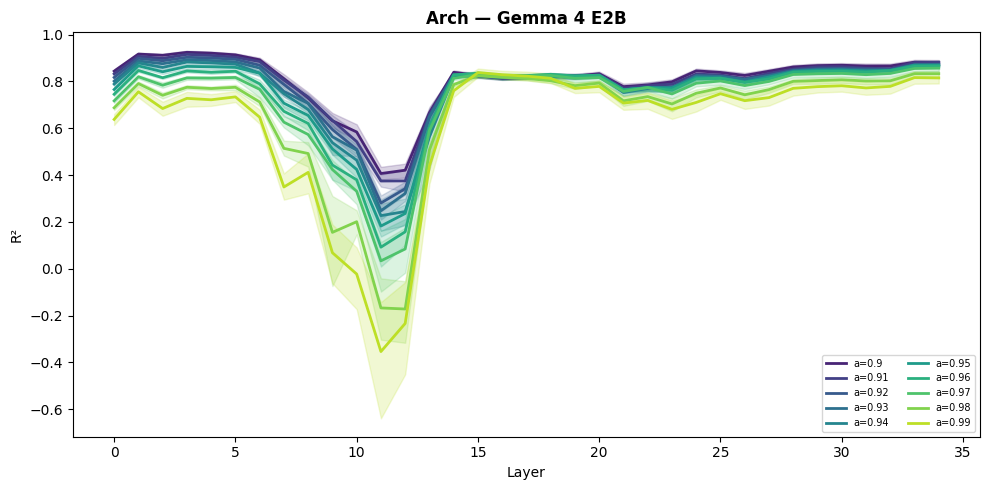

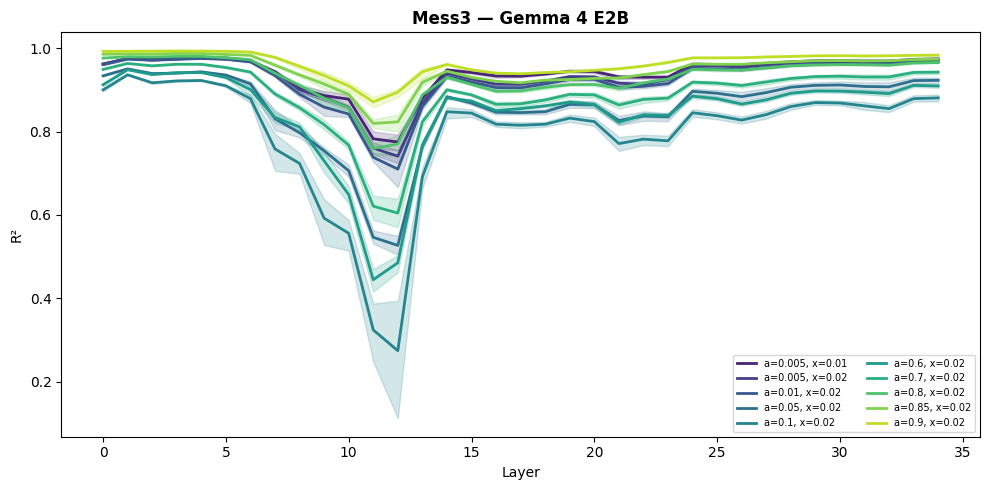

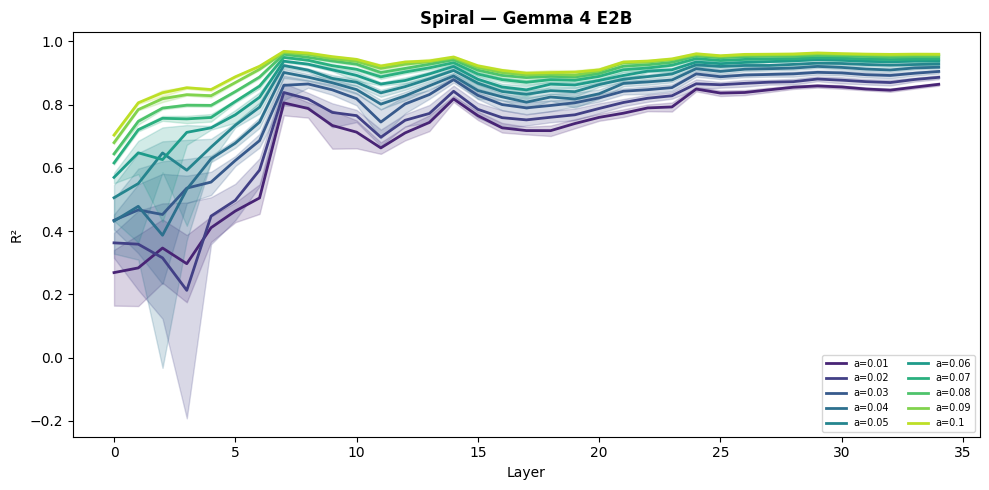

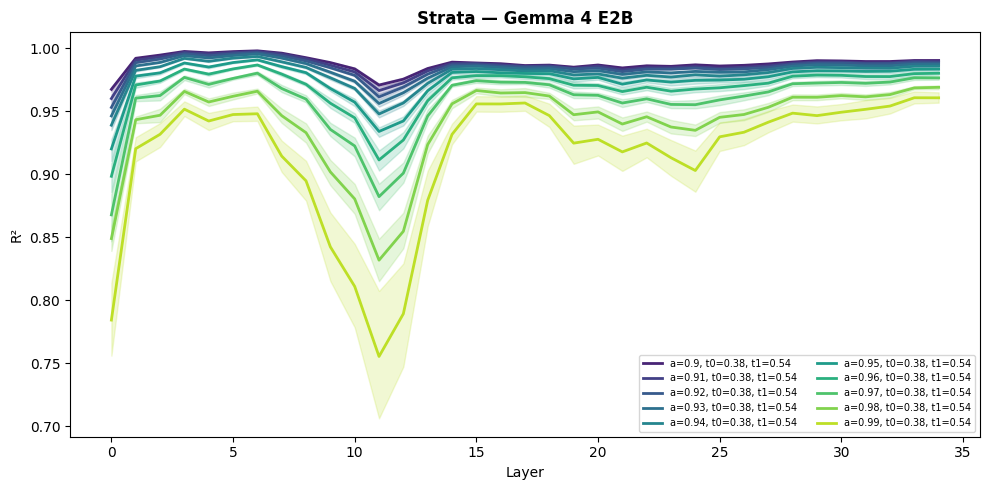

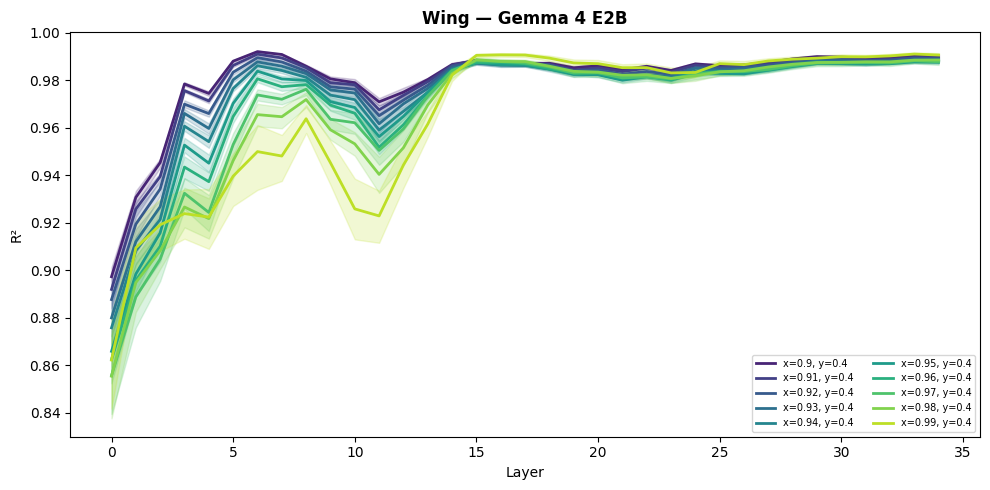

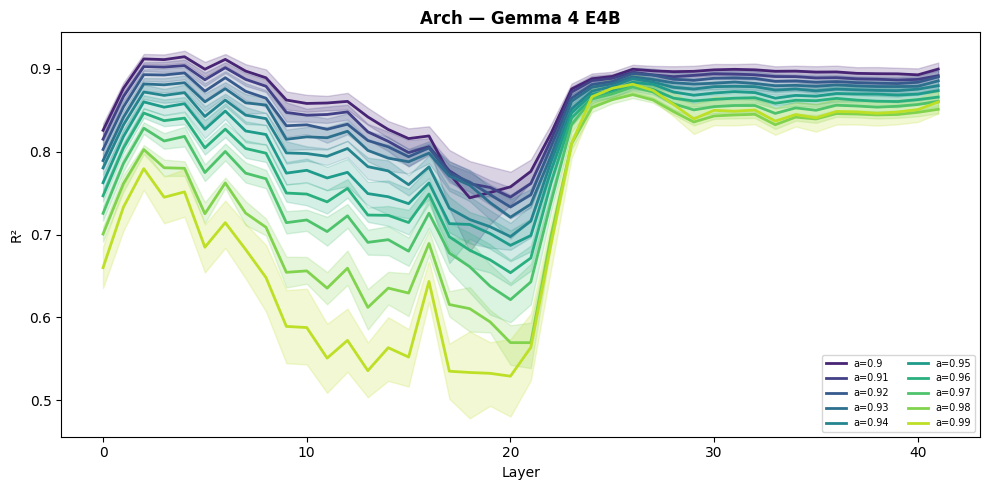

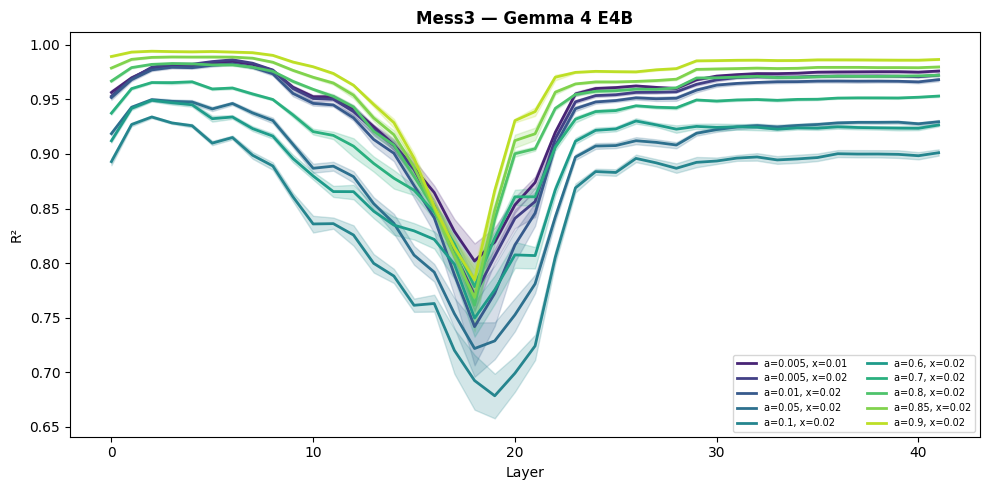

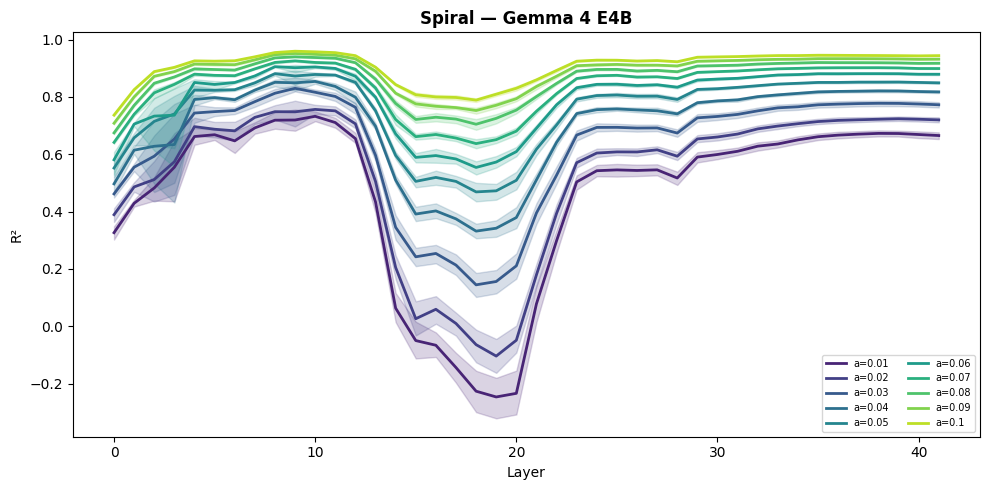

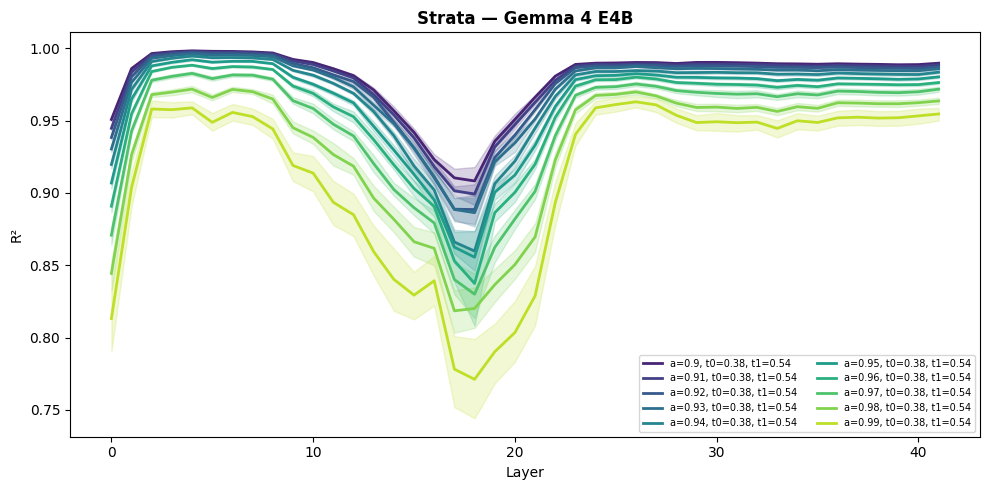

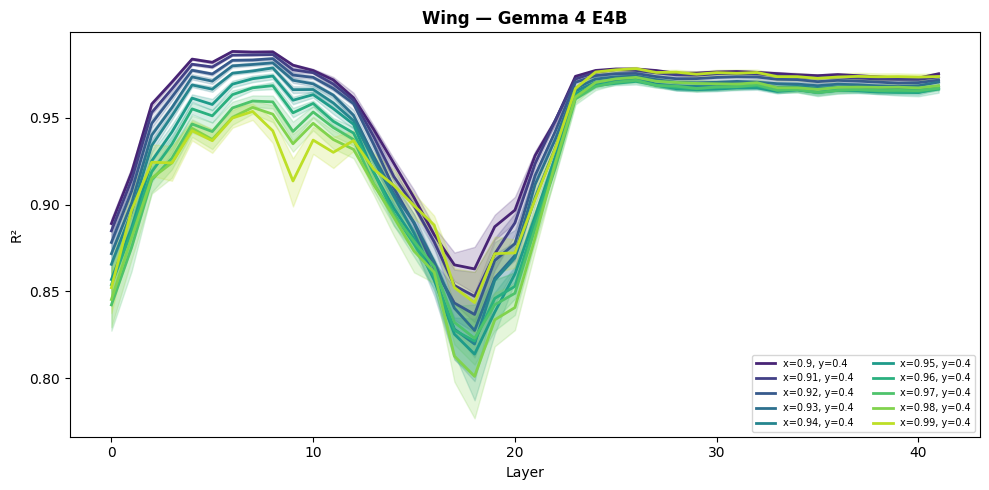

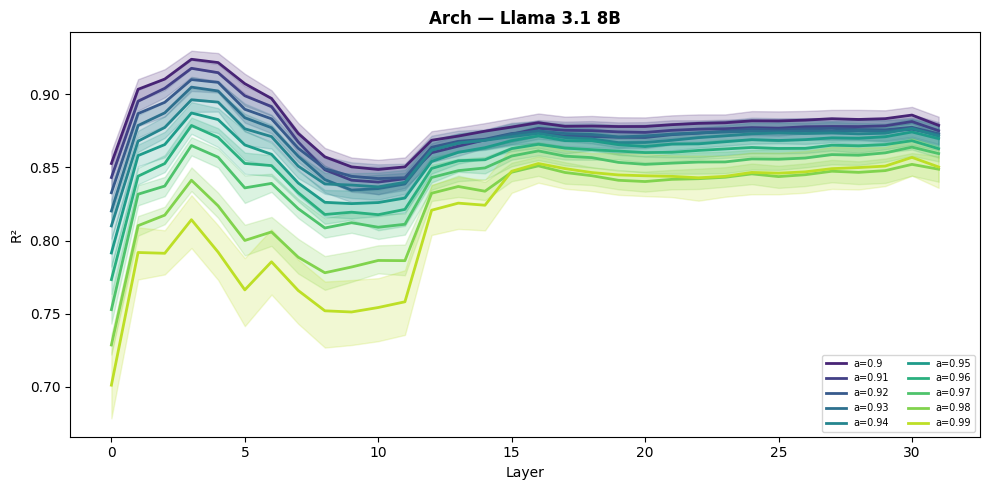

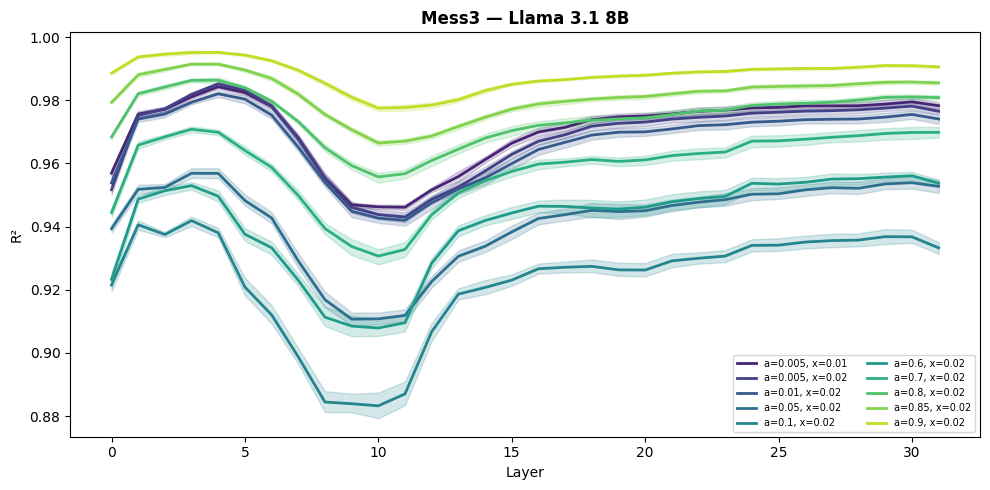

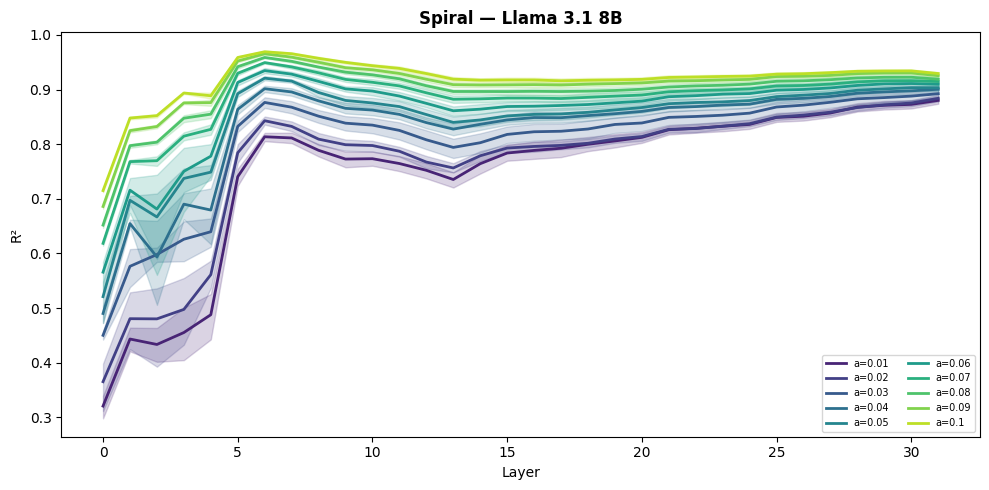

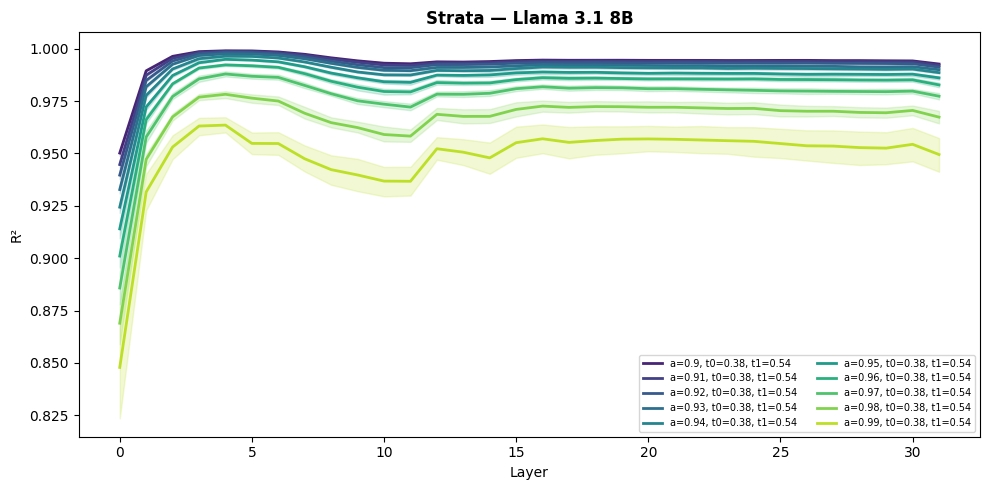

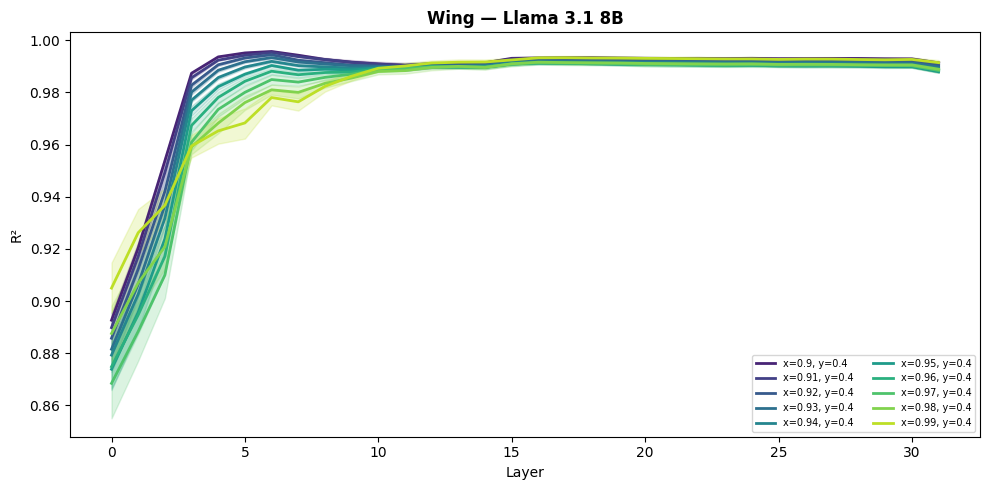

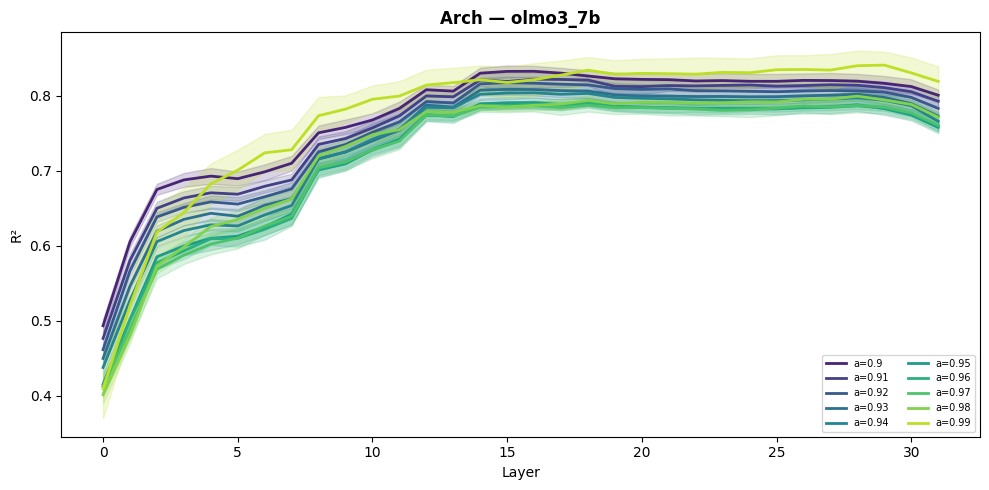

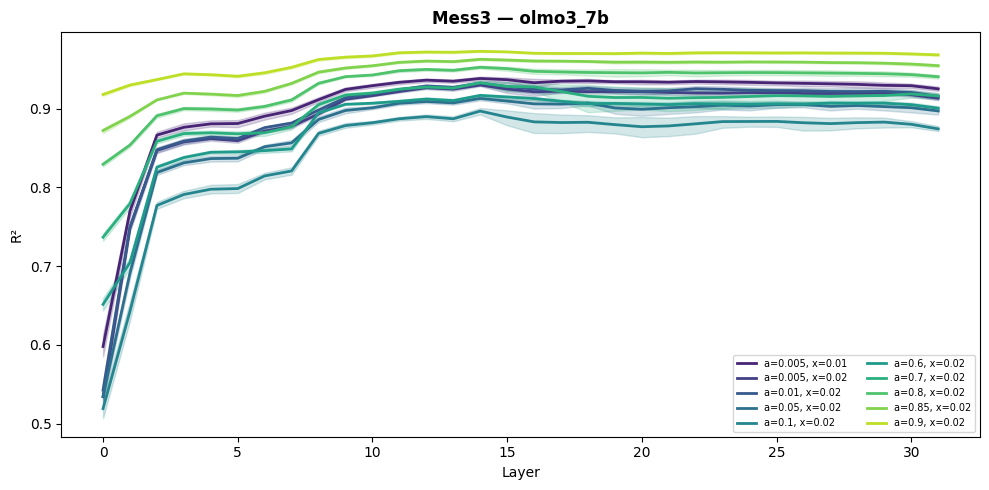

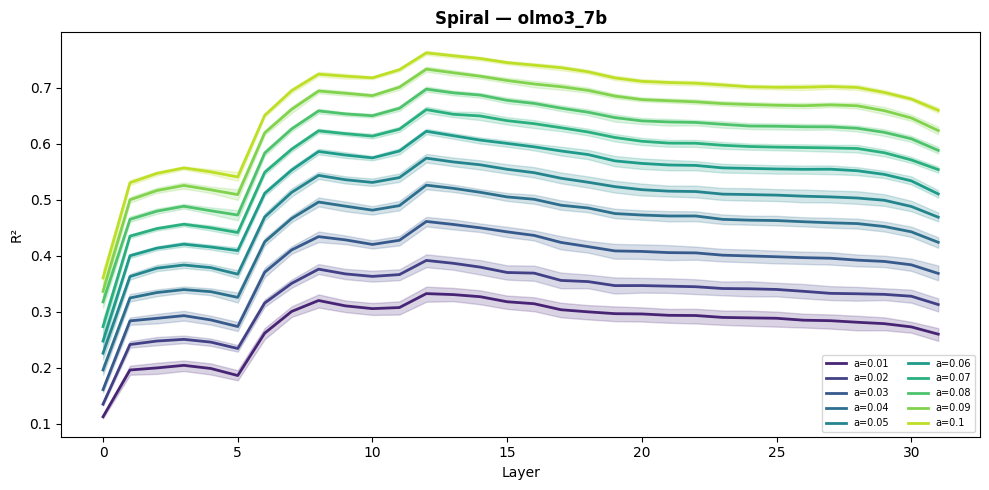

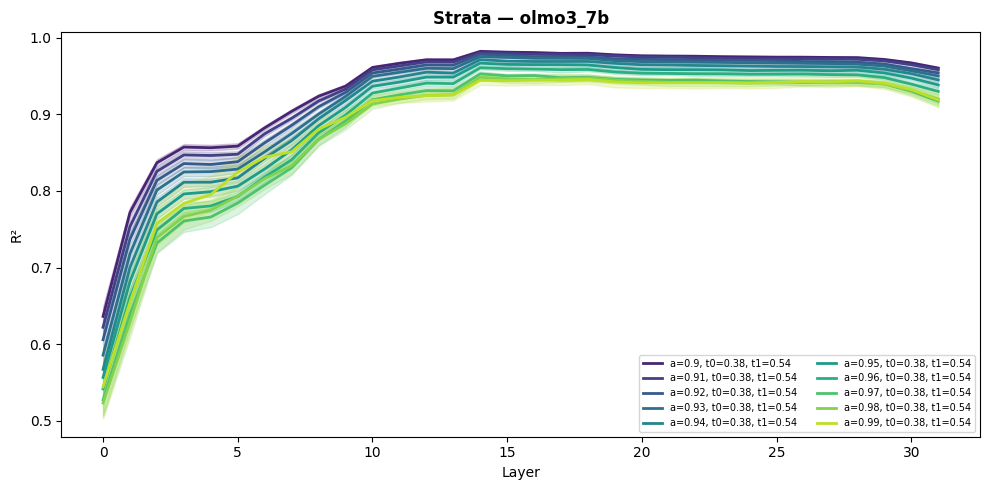

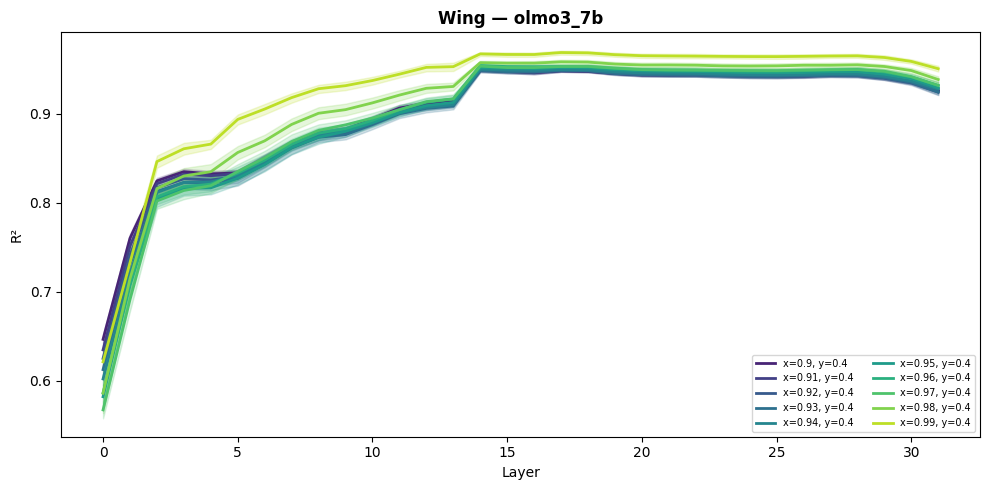

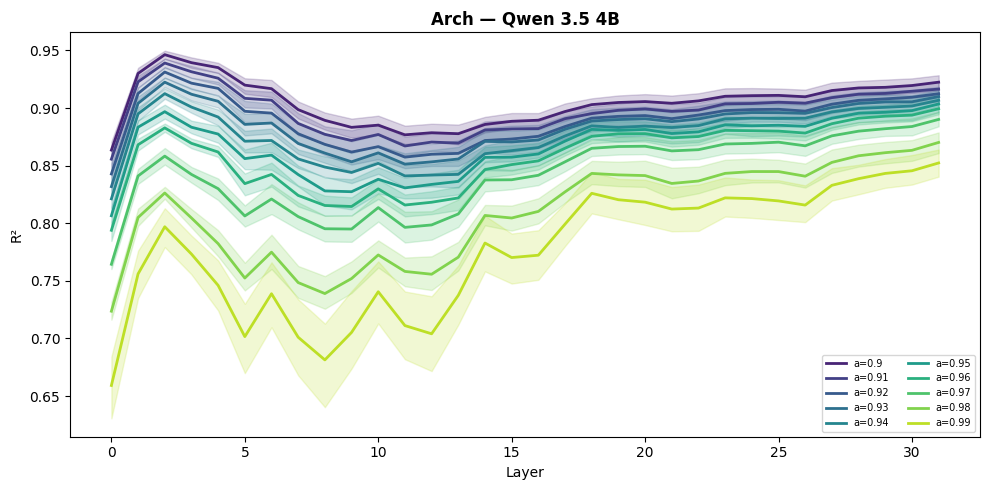

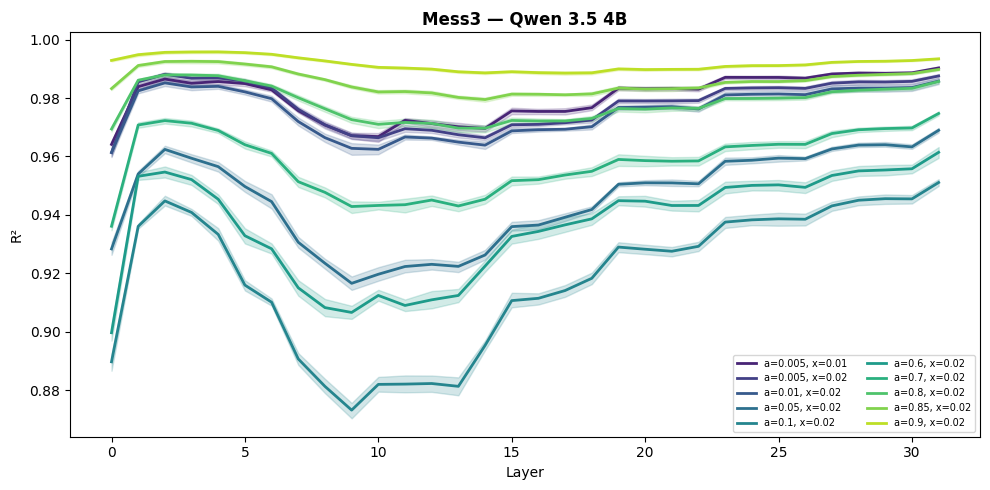

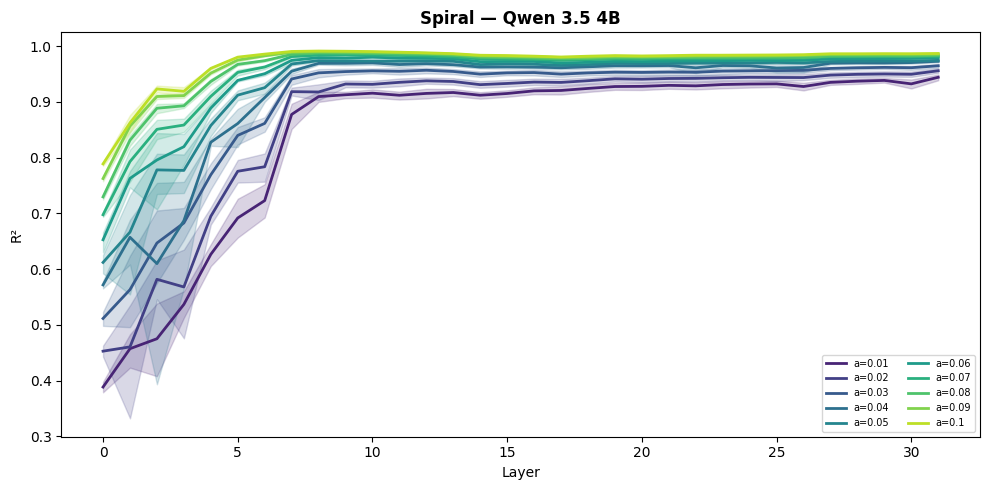

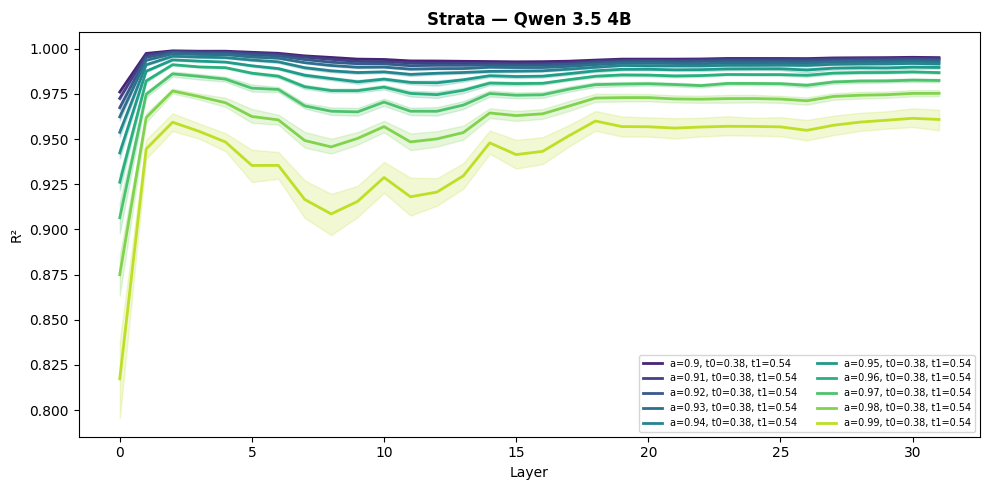

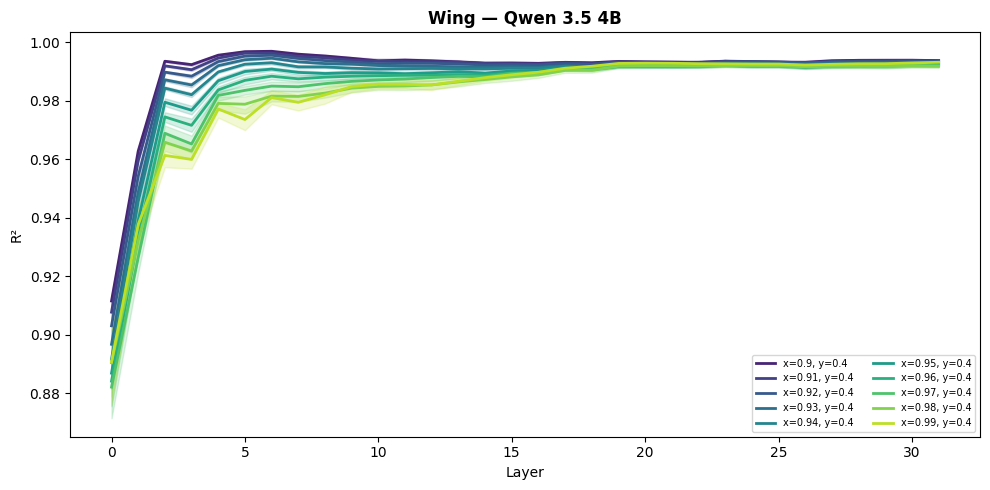

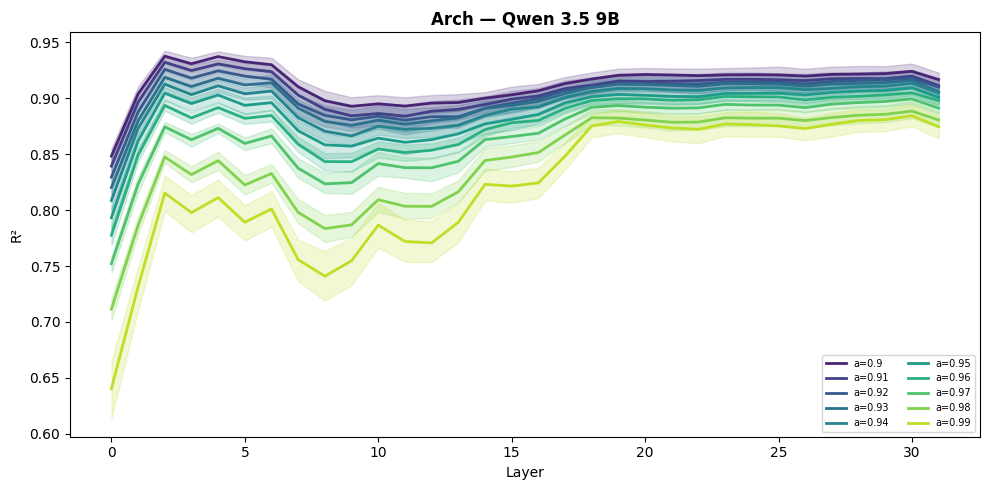

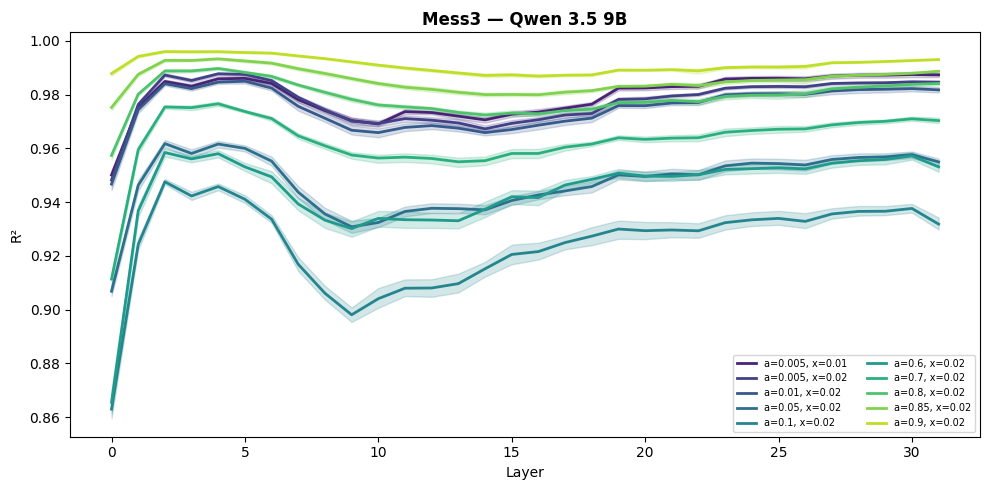

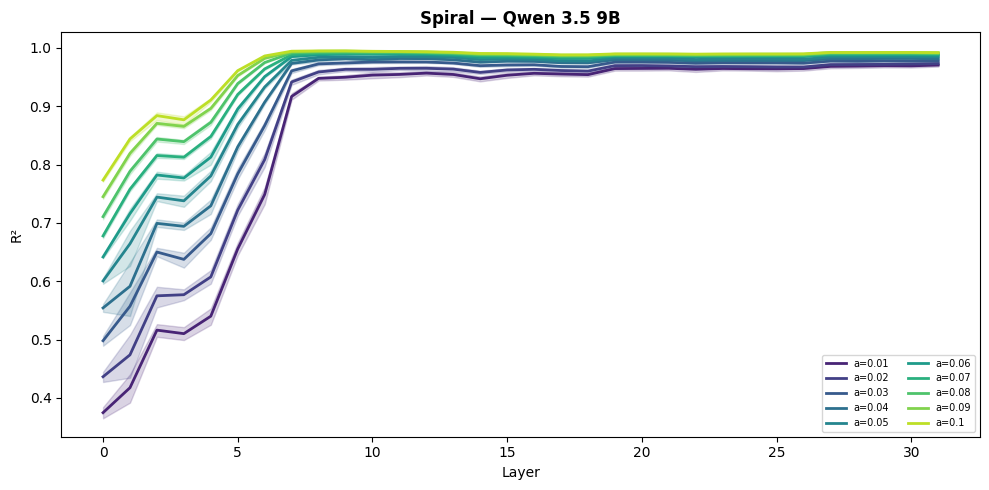

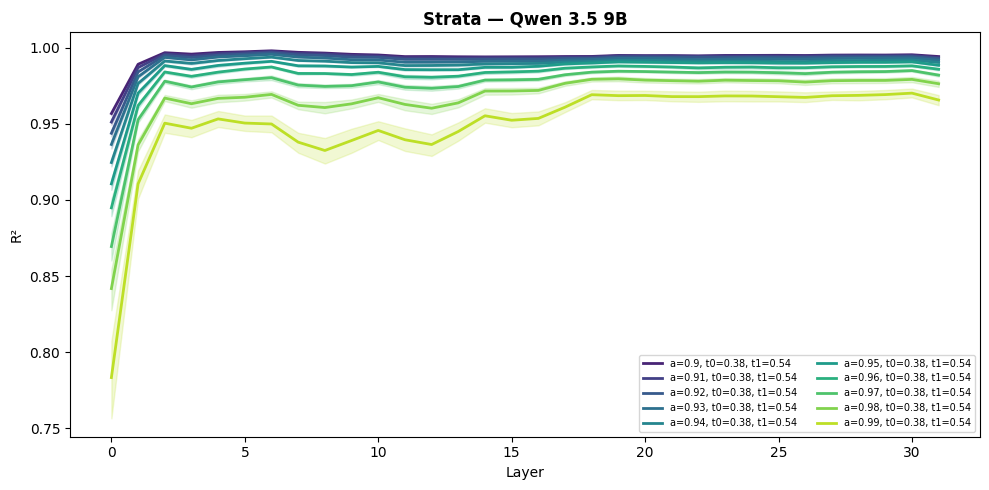

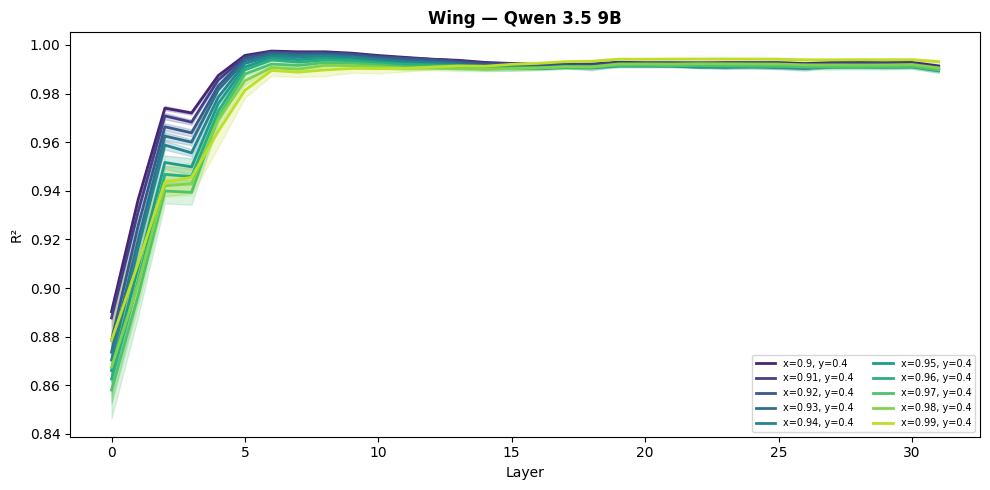

In [2]:
model_labels = {
    'qwen35_4b': 'Qwen 3.5 4B',
    'qwen35_9b': 'Qwen 3.5 9B',
    'llama31_8b': 'Llama 3.1 8B',
    'gemma4_e2b': 'Gemma 4 E2B',
    'gemma4_e4b': 'Gemma 4 E4B',
}

for model_short, df in files.items():
    model_name = model_labels.get(model_short, model_short)
    real = df[df['target'] == 'real']

    for hmm_name in sorted(real['hmm'].unique()):
        hmm_data = real[real['hmm'] == hmm_name]
        params = sorted(hmm_data['param'].unique())
        cmap = plt.cm.viridis(np.linspace(0.1, 0.9, len(params)))

        fig, ax = plt.subplots(figsize=(10, 5))
        for i, param in enumerate(params):
            sub = hmm_data[hmm_data['param'] == param]
            sns.lineplot(data=sub, x='layer', y='R2', color=cmap[i],
                         errorbar=('ci', 95), lw=2, label=param, ax=ax)

        ax.set_xlabel('Layer')
        ax.set_ylabel('R²')
        ax.set_title(f'{hmm_name} — {model_name}', fontweight='bold')
        ax.legend(fontsize=7, ncol=2, loc='lower right')
        plt.tight_layout()
        plt.show()
        plt.close()

In [10]:
# Peak R² in early-to-middle layers per (model, HMM, param)
for model_short, df in files.items():
    model_name = model_labels.get(model_short, model_short)
    real = df[df['target'] == 'real']
    n_layers = real['layer'].max() + 1
    mid = n_layers // 2

    print(f'\n{"="*60}')
    print(f'{model_name} (layers 0–{mid})')
    print(f'{"="*60}')

    for hmm_name in sorted(real['hmm'].unique()):
        print(f'\n  {hmm_name}:')
        hmm_data = real[(real['hmm'] == hmm_name) & (real['layer'] <= mid)]
        for param in sorted(hmm_data['param'].unique()):
            sub = hmm_data[hmm_data['param'] == param]
            stats = sub.groupby('layer')['R2'].mean()
            peak_r2 = stats.max()
            peak_layer = stats.idxmax()
            print(f'    {param:>35s}: peak R²={peak_r2:.4f} at layer {int(peak_layer)}')


Gemma 4 E2B (layers 0–17)

  Arch:
                                  a=0.9: peak R²=0.9241 at layer 3
                                 a=0.91: peak R²=0.9153 at layer 3
                                 a=0.92: peak R²=0.9029 at layer 3
                                 a=0.93: peak R²=0.8920 at layer 3
                                 a=0.94: peak R²=0.8826 at layer 3
                                 a=0.95: peak R²=0.8663 at layer 1
                                 a=0.96: peak R²=0.8466 at layer 1
                                 a=0.97: peak R²=0.8298 at layer 15
                                 a=0.98: peak R²=0.8239 at layer 15
                                 a=0.99: peak R²=0.8377 at layer 15

  Mess3:
                        a=0.005, x=0.01: peak R²=0.9764 at layer 4
                        a=0.005, x=0.02: peak R²=0.9783 at layer 4
                         a=0.01, x=0.02: peak R²=0.9756 at layer 4
                         a=0.05, x=0.02: peak R²=0.9504 at layer 1
             

In [16]:
# For each (model, HMM, param): peak R² in early-to-middle layers. Then grand average.
peaks = []

for model_short, df in files.items():
    if 'olmo' in model_short:
        continue
    model_name = model_labels.get(model_short, model_short)
    real = df[(df['target'] == 'real') & (df['hmm'] != 'Spiral')]
    n_layers = real['layer'].max() + 1
    mid = n_layers // 2

    for hmm_name in sorted(real['hmm'].unique()):
        for param in sorted(real[real['hmm'] == hmm_name]['param'].unique()):
            sub = real[(real['hmm'] == hmm_name) & (real['param'] == param) & (real['layer'] <= mid)]
            peak_r2 = sub.groupby('layer')['R2'].mean().max()
            peaks.append({'model': model_name, 'hmm': hmm_name, 'param': param, 'peak_R2': peak_r2})

peaks_df = pd.DataFrame(peaks)
print(f'Grand mean peak R² = {peaks_df["peak_R2"].mean():.4f} ± {peaks_df["peak_R2"].std():.4f}')
print(f'Range: [{peaks_df["peak_R2"].min():.4f}, {peaks_df["peak_R2"].max():.4f}]')
print(f'N = {len(peaks_df)} (model × HMM × param)')

Grand mean peak R² = 0.9590 ± 0.0498
Range: [0.7796, 0.9991]
N = 240 (model × HMM × param)


In [15]:
# For each (model, HMM, param): peak R² across layers. Then grand average.
peaks = []

for model_short, df in files.items():
    if 'olmo' in model_short:
        continue
    model_name = model_labels.get(model_short, model_short)
    real = df[(df['target'] == 'real') & (df['hmm'] != 'Spiral')]

    for hmm_name in sorted(real['hmm'].unique()):
        for param in sorted(real[real['hmm'] == hmm_name]['param'].unique()):
            sub = real[(real['hmm'] == hmm_name) & (real['param'] == param)]
            peak_r2 = sub.groupby('layer')['R2'].mean().max()
            peaks.append({'model': model_name, 'hmm': hmm_name, 'param': param, 'peak_R2': peak_r2})

peaks_df = pd.DataFrame(peaks)
print(f'Grand mean peak R² = {peaks_df["peak_R2"].mean():.4f} ± {peaks_df["peak_R2"].std():.4f}')
print(f'Range: [{peaks_df["peak_R2"].min():.4f}, {peaks_df["peak_R2"].max():.4f}]')
print(f'N = {len(peaks_df)} (model × HMM × param)')

Grand mean peak R² = 0.9625 ± 0.0432
Range: [0.8321, 0.9991]
N = 240 (model × HMM × param)


In [19]:
# Print R²(real, shuffle, random) averaged over seeds per layer — Qwen 3.5 9B only
df = files['qwen35_9b']
model_name = 'Qwen 3.5 9B'

for hmm_name in sorted(df[df['hmm'] != 'Spiral']['hmm'].unique()):
    for param in sorted(df[df['hmm'] == hmm_name]['param'].unique()):
        sub = df[(df['hmm'] == hmm_name) & (df['param'] == param)]
        layers = sorted(sub['layer'].unique())

        print(f'\n    {hmm_name} {param} (mean over {sub["seed"].nunique()} seeds):')
        print(f'    {"L":>4}  {"real":>10}  {"shuffle":>10}  {"random":>10}')
        for layer in layers:
            ldf = sub[sub['layer'] == layer]
            r2_r = ldf[ldf['target'] == 'real']['R2'].mean()
            r2_s = ldf[ldf['target'] == 'shuffle']['R2'].mean()
            r2_d = ldf[ldf['target'] == 'random']['R2'].mean()
            print(f'    {layer:4d}  {r2_r:10.4f}  {r2_s:10.4f}  {r2_d:10.4f}')


    Arch a=0.9 (mean over 10 seeds):
       L        real     shuffle      random
       0      0.8481     -0.0486     -0.0481
       1      0.9038     -0.1329     -0.1310
       2      0.9375     -0.3271     -0.3256
       3      0.9308     -0.2680     -0.2706
       4      0.9371     -0.3785     -0.3917
       5      0.9325     -0.5629     -0.5585
       6      0.9299     -0.9968     -0.9984
       7      0.9102     -1.1809     -1.1598
       8      0.8977     -1.4010     -1.4228
       9      0.8927     -1.4308     -1.4138
      10      0.8950     -1.4601     -1.4493
      11      0.8929     -1.4514     -1.4111
      12      0.8956     -1.4247     -1.3709
      13      0.8961     -1.4110     -1.3432
      14      0.9000     -1.4222     -1.3931
      15      0.9030     -1.3917     -1.3698
      16      0.9066     -1.3466     -1.3371
      17      0.9131     -1.3293     -1.3388
      18      0.9171     -1.4070     -1.3984
      19      0.9204     -1.4218     -1.4170
      20      0.9

In [411]:
targets = [
    ('Mess3', 'a=0.01, x=0.02'),
    ('Arch', 'a=0.9'),
    ('Wing', 'x=0.98, y=0.4'),
    ('Strata', 'a=0.97, t0=0.38, t1=0.54'),
]

colors = {'LLM': 'black', 'Order-1': 'blue', 'Order-0': 'red'}

## KL

In [412]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load KL CSV
kl_df = pd.read_csv('final_kl_csv/kl_orderk_qwen35_9b.csv')

In [413]:
last5k = kl_df[kl_df['position'] >= 15000]

per_seed = (last5k
    .groupby(['hmm', 'param', 'source', 'seed'])['KL']
    .mean()
    .reset_index()
    .rename(columns={'KL': 'KL_mean'})
)

summary = (per_seed
    .groupby(['hmm', 'param', 'source'])
    .agg(KL_mean=('KL_mean', 'mean'), KL_std=('KL_mean', 'std'))
    .reset_index()
)

print(f'per_seed: {len(per_seed)} rows')
print(f'summary: {len(summary)} rows')
print(summary)

per_seed.to_csv('kl_summary_per_seed.csv', index=False)
summary.to_csv('kl_summary.csv', index=False)

per_seed: 1500 rows
summary: 150 rows
      hmm          param   source   KL_mean    KL_std
0    Arch          a=0.9      LLM  0.009504  0.000742
1    Arch          a=0.9  Order-0  0.045645  0.001949
2    Arch          a=0.9  Order-1  0.026155  0.001030
3    Arch         a=0.91      LLM  0.010006  0.000596
4    Arch         a=0.91  Order-0  0.047969  0.002810
..    ...            ...      ...       ...       ...
145  Wing  x=0.98, y=0.4  Order-0  0.113191  0.004194
146  Wing  x=0.98, y=0.4  Order-1  0.081891  0.004657
147  Wing  x=0.99, y=0.4      LLM  0.010090  0.001494
148  Wing  x=0.99, y=0.4  Order-0  0.133226  0.004897
149  Wing  x=0.99, y=0.4  Order-1  0.100161  0.006331

[150 rows x 5 columns]


In [414]:
target_set = set(targets)
kl_repr = summary[(summary['source'] == 'LLM') &
                   (summary['hmm'] != 'Spiral') &
                   summary.apply(lambda r: (r['hmm'], r['param']) in target_set, axis=1)]
print(kl_repr[['hmm', 'param', 'KL_mean', 'KL_std']].to_string(index=False))

   hmm                    param  KL_mean   KL_std
  Arch                    a=0.9 0.009504 0.000742
 Mess3           a=0.01, x=0.02 0.018137 0.001245
Strata a=0.97, t0=0.38, t1=0.54 0.010426 0.001515
  Wing            x=0.98, y=0.4 0.011441 0.001428


In [338]:
kl_k = pd.read_csv('kl_vs_k_summary.csv')
kl_llm = summary[(summary['source'] == 'LLM') & (summary['hmm'] != 'Spiral')]

# For each hmm × param, find the k where order-k KL first drops below LLM's converged KL
rows = []
for _, row in kl_llm.iterrows():
    sub = kl_k[(kl_k['hmm'] == row['hmm']) & (kl_k['param'] == row['param'])].sort_values('k')
    if len(sub) == 0:
        continue
    match_k = sub[sub['mean'] <= row['KL_mean']]['k']
    k_val = int(match_k.min()) if len(match_k) > 0 else '>20'
    rows.append({'hmm': row['hmm'], 'param': row['param'],
                 'KL_LLM': row['KL_mean'], 'KL_k1': sub[sub['k']==1]['mean'].values[0],
                 'crossover_k': k_val})

crossover = pd.DataFrame(rows)
print(crossover.to_string(index=False))

print(f'\nMatched {len(crossover)}/{len(kl_llm)} params')
print(f'kl_k params per HMM:')
print(kl_k.groupby('hmm')['param'].nunique())

# Summary per family
print('\n--- Crossover k per family ---')
for hmm in ['Mess3', 'Arch', 'Wing', 'Strata']:
    sub = crossover[crossover['hmm'] == hmm]
    numeric = sub[sub['crossover_k'] != '>20']['crossover_k'].astype(int)
    if len(numeric):
        print(f'  {hmm}: median k={numeric.median():.0f}, range=[{numeric.min()}, {numeric.max()}]')
    else:
        print(f'  {hmm}: all >20')

   hmm                    param   KL_LLM    KL_k1  crossover_k
  Arch                    a=0.9 0.009504 0.026130            3
 Mess3           a=0.01, x=0.02 0.018137 0.175450            5
Strata a=0.97, t0=0.38, t1=0.54 0.010426 0.075068            6
  Wing            x=0.98, y=0.4 0.011441 0.081874            6

Matched 4/40 params
kl_k params per HMM:
hmm
Arch      1
Mess3     1
Strata    1
Wing      1
Name: param, dtype: int64

--- Crossover k per family ---
  Mess3: median k=5, range=[5, 5]
  Arch: median k=3, range=[3, 3]
  Wing: median k=6, range=[6, 6]
  Strata: median k=6, range=[6, 6]


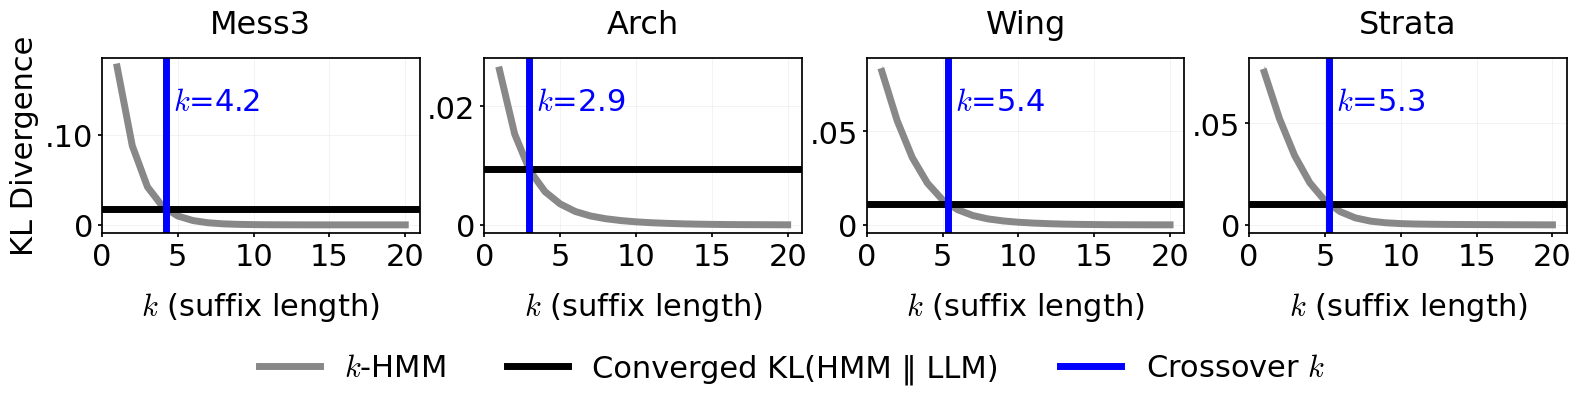

In [377]:
import matplotlib
matplotlib.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'font.weight': 'light',
})

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

sns.set_context('notebook')
tab10 = sns.color_palette('tab10')

def fmt_tick(v):
    if v == int(v):
        return str(int(v))
    s = f'{v:.2f}'
    if '.' in s and -1 < v < 1:
        s = s.lstrip('0')
    return s

n_seeds = 10

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))

hmm_order = ['Mess3', 'Arch', 'Wing', 'Strata']

for i, (ax, hmm) in enumerate(zip(axes, hmm_order)):
    param = kl_k[kl_k['hmm'] == hmm]['param'].iloc[0]
    sub = kl_k[(kl_k['hmm'] == hmm) & (kl_k['param'] == param)].sort_values('k')
    llm_kl = kl_llm[(kl_llm['hmm'] == hmm) & (kl_llm['param'] == param)]['KL_mean'].values[0]

    # Order-k curve with 95% CI
    sem = sub['std'] / np.sqrt(n_seeds)
    ax.plot(sub['k'], sub['mean'], color='#888888', lw=5,
            label=r'$k$-token Bayesian predictor')
    ax.fill_between(sub['k'], sub['mean'] - 1.96 * sem, sub['mean'] + 1.96 * sem,
                    alpha=0.15, color='black')

    # LLM converged KL
    ax.axhline(llm_kl, color='black', ls='-', lw=5,
               label=r'LLM converged $\overline{KL}$')

    # Mark crossover (interpolated)
    cross = crossover[(crossover['hmm'] == hmm) & (crossover['param'] == param)]
    if len(cross) and cross.iloc[0]['crossover_k'] != '>20':
        k_star = int(cross.iloc[0]['crossover_k'])
        kl_at = sub.set_index('k')['mean']
        kl_above = kl_at[k_star - 1]
        kl_below = kl_at[k_star]
        frac = (kl_above - llm_kl) / (kl_above - kl_below)
        k_cross = (k_star - 1) + frac
        ax.axvline(k_cross, color='blue', ls='-', lw=5,
                   label=f'Crossover $k \\approx {k_cross:.1f}$')

    ax.set_title(f'{hmm}', fontsize=23, pad=18)
    ax.set_xticks([0, 5, 10, 15, 20])
    ax.set_xlabel('$k$ (suffix length)', fontsize=22, labelpad=14)
    ax.tick_params(axis='both', labelsize=22, length=3)
    ax.grid(True, alpha=0.2, linewidth=0.5)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: fmt_tick(v)))
    if i == 0:
        ax.set_ylabel('KL Divergence', fontsize=22)

    ax.annotate(f'$k$={k_cross:.1f}',
                    xy=(k_cross, 0.7), xycoords=('data', 'axes fraction'),
                    fontsize=22, color='blue', ha='left',
                    xytext=(5, 0), textcoords='offset points')

# Legend below
legend_handles = [
    Line2D([], [], color='#888888', lw=5, label=r'$k$' + '-HMM'),
    Line2D([], [], color='black', lw=5, ls='-', label='Converged KL(HMM ‖ LLM)'),
    Line2D([], [], color='blue', lw=5, ls='-', label='Crossover $k$'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=3,
           fontsize=22, frameon=False, bbox_to_anchor=(0.5, -0.2))

plt.tight_layout(w_pad=0)
plt.savefig('plots/kl_vs_k.pdf', bbox_inches='tight')
plt.show()
plt.close()

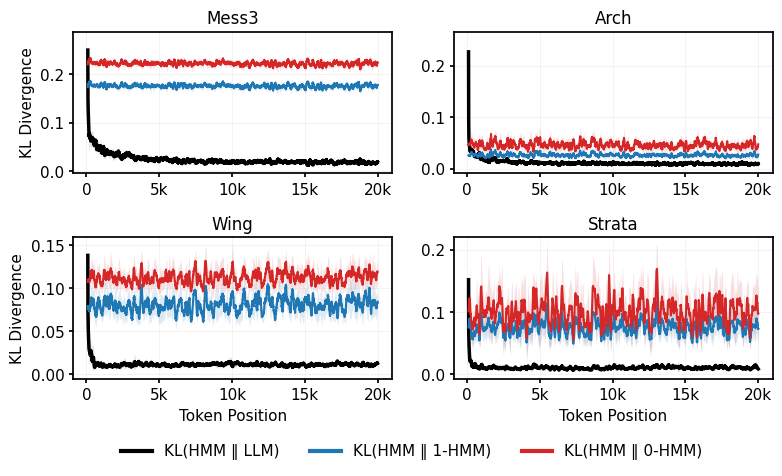

In [238]:
matplotlib.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'font.weight': 'light',
})
sns.set_context('notebook')

fig, axes = plt.subplots(2, 2, figsize=(8, 4.5))

labels = {'LLM': 'KL(HMM ‖ LLM)', 'Order-1': 'KL(HMM ‖ 1-HMM)', 'Order-0': 'KL(HMM ‖ 0-HMM)'}
tab10 = sns.color_palette('tab10')
colors = {'LLM': 'black', 'Order-1': tab10[0], 'Order-0': tab10[3]}

for i, (hmm, param) in enumerate(targets):
    row, col = divmod(i, 2)
    ax = axes[row, col]
    sub = kl_df[(kl_df['hmm'] == hmm) & (kl_df['param'] == param)]
    if len(sub) == 0:
        ax.set_title(f'{hmm} ({param}): no data')
        continue

    for source in ['LLM', 'Order-1', 'Order-0']:
        s = sub[sub['source'] == source]
        stats = s.groupby('position')['KL'].agg(['mean', 'sem']).reset_index()
        lw = 2.5 if source == 'LLM' else 1.5
        ax.plot(stats['position'], stats['mean'], color=colors[source], lw=lw, label=labels[source])
        ax.fill_between(stats['position'],
                        stats['mean'] - 1.96 * stats['sem'],
                        stats['mean'] + 1.96 * stats['sem'],
                        color=colors[source], alpha=0.15, linewidth=0)

    ax.set_title(f'{hmm}', fontsize=12)
    ax.set_xticks([0, 5000, 10000, 15000, 20000])
    ax.set_xticklabels(['0', '5k', '10k', '15k', '20k'])
    ax.tick_params(axis='both', labelsize=11, length=3)
    if row == 1:
        ax.set_xlabel('Token Position', fontsize=11)
    if col == 0:
        ax.set_ylabel('KL Divergence', fontsize=11)
    ax.grid(True, alpha=0.2, linewidth=0.5)

# Legend on top
from matplotlib.lines import Line2D
legend_handles = [Line2D([], [], color=colors[s], lw=3, label=labels[s])
                  for s in ['LLM', 'Order-1', 'Order-0']]
fig.legend(handles=legend_handles, loc='upper center', ncol=3,
           fontsize=11, frameon=False, bbox_to_anchor=(0.525, 0.025))

plt.tight_layout()
plt.savefig('plots/kl.pdf', bbox_inches='tight')
plt.show()
plt.close()

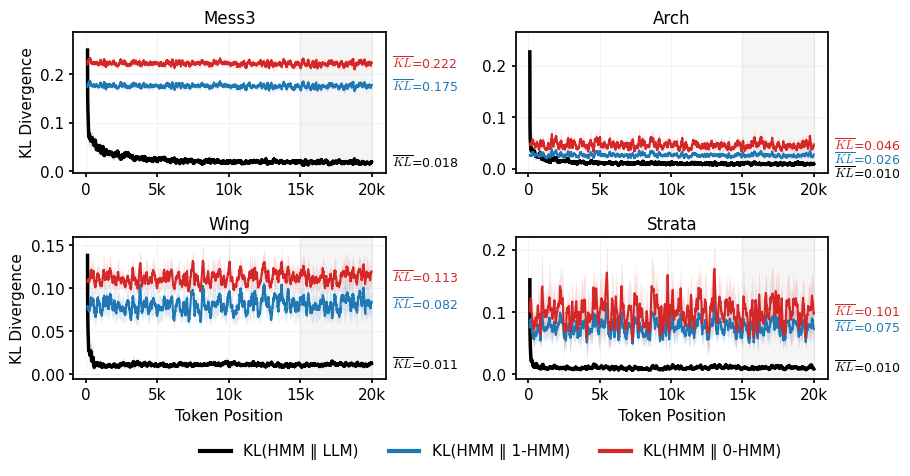

In [359]:
matplotlib.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'font.weight': 'light',
})
sns.set_context('notebook')

fig, axes = plt.subplots(2, 2, figsize=(9.5, 4.5))

labels = {'LLM': 'KL(HMM ‖ LLM)', 'Order-1': 'KL(HMM ‖ 1-HMM)', 'Order-0': 'KL(HMM ‖ 0-HMM)'}
tab10 = sns.color_palette('tab10')
colors = {'LLM': 'black', 'Order-1': tab10[0], 'Order-0': tab10[3]}

for i, (hmm, param) in enumerate(targets):
    row, col = divmod(i, 2)
    ax = axes[row, col]
    sub = kl_df[(kl_df['hmm'] == hmm) & (kl_df['param'] == param)]
    if len(sub) == 0:
        ax.set_title(f'{hmm} ({param}): no data')
        continue

    for source in ['LLM', 'Order-1', 'Order-0']:
        s = sub[sub['source'] == source]
        stats = s.groupby('position')['KL'].agg(['mean', 'sem']).reset_index()
        lw = 2.5 if source == 'LLM' else 1.5
        ax.plot(stats['position'], stats['mean'], color=colors[source], lw=lw, label=labels[source])
        ax.fill_between(stats['position'],
                        stats['mean'] - 1.96 * stats['sem'],
                        stats['mean'] + 1.96 * stats['sem'],
                        color=colors[source], alpha=0.15, linewidth=0)

    # Shaded convergence window
    ax.axvspan(15000, 20000, alpha=0.08, color='gray', zorder=0)

    # Annotate converged values outside right y-axis
    conv_vals = {}
    for source in ['LLM', 'Order-1', 'Order-0']:
        s = sub[sub['source'] == source]
        conv_vals[source] = s[s['position'] >= 15000].groupby('position')['KL'].mean().mean()

    # Always stack top-to-bottom: Order-0, Order-1, LLM
    sorted_sources = sorted(conv_vals, key=lambda s: conv_vals[s], reverse=True)
    ax_range = ax.get_ylim()[1] - ax.get_ylim()[0]
    min_gap = ax_range * 0.10
    y_positions = {}
    for j, source in enumerate(sorted_sources):
        if j == 0:
            y_positions[source] = conv_vals[source]
        else:
            prev = sorted_sources[j - 1]
            natural = conv_vals[source]
            forced = y_positions[prev] - min_gap
            y_positions[source] = min(natural, forced)

    for source in sorted_sources:
        ax.annotate(r'$\overline{KL}$' + f'={conv_vals[source]:.3f}',
                    xy=(1.02, y_positions[source]), xycoords=('axes fraction', 'data'),
                    fontsize=9, color=colors[source], va='center', ha='left',
                    clip_on=False)

    ax.set_title(f'{hmm}', fontsize=12)
    ax.set_xticks([0, 5000, 10000, 15000, 20000])
    ax.set_xticklabels(['0', '5k', '10k', '15k', '20k'])
    ax.tick_params(axis='both', labelsize=11, length=3)
    if row == 1:
        ax.set_xlabel('Token Position', fontsize=11)
    if col == 0:
        ax.set_ylabel('KL Divergence', fontsize=11)
    ax.grid(True, alpha=0.2, linewidth=0.5)

# Legend on top
from matplotlib.lines import Line2D
legend_handles = [Line2D([], [], color=colors[s], lw=3, label=labels[s])
                  for s in ['LLM', 'Order-1', 'Order-0']]
fig.legend(handles=legend_handles, loc='upper center', ncol=3,
           fontsize=11, frameon=False, bbox_to_anchor=(0.525, 0.025))

plt.tight_layout()
plt.subplots_adjust(right=0.88)
plt.savefig('plots/kl.pdf', bbox_inches='tight')
plt.show()
plt.close()

## R2 + shuffle + random

In [415]:
# Load R² CSV
r2_df = pd.read_csv('final_r2_csv/r2_qwen35_9b.csv')

# Load geometry data
gd = np.load('final_geom_npz/geom_qwen35_9b.npz', allow_pickle=True)

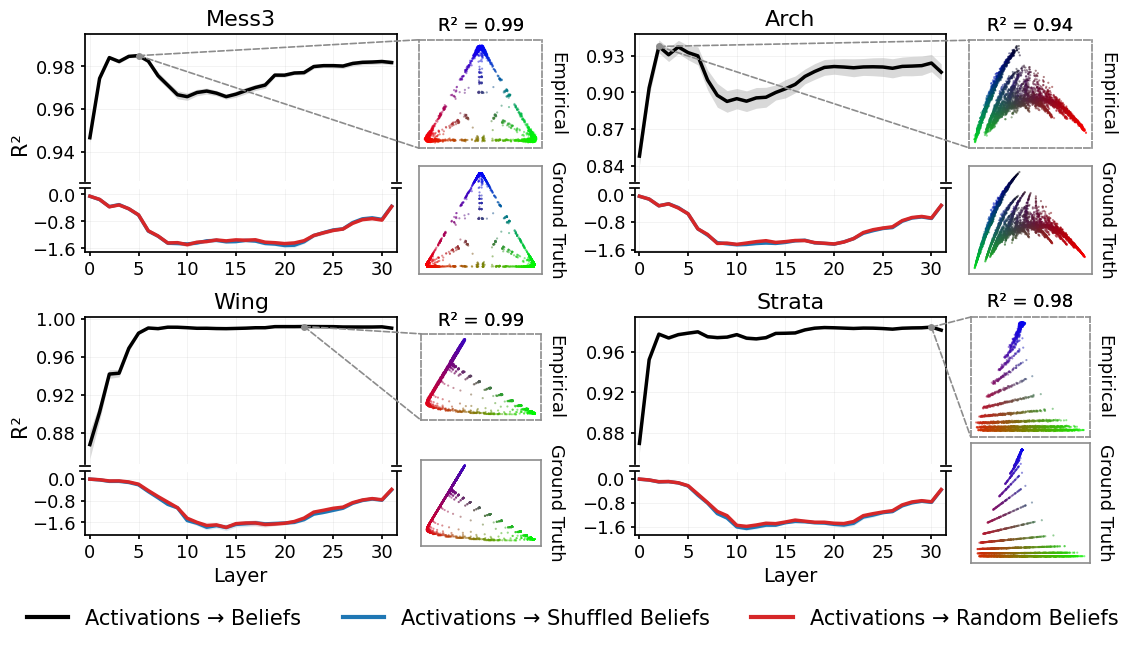

In [416]:
import matplotlib
matplotlib.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'font.weight': 'light',
})

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set_context('notebook')

tab10 = sns.color_palette('tab10')
target_styles = {
    'real': ('black', 2.5, 'Activations → Beliefs'),
    'shuffle': (tab10[0], 2.5, 'Activations → Shuffled Beliefs'),
    'random': (tab10[3], 2.5, 'Activations → Random Beliefs'),
}

CONN_COLOR = '0.55'

fig = plt.figure(figsize=(13, 6.5))
fig.patch.set_facecolor('white')
fig.patch.set_edgecolor('white')
fig.patch.set_linewidth(0)
outer = fig.add_gridspec(2, 2, wspace=0.2, hspace=0.3)

# Shared legend at top
from matplotlib.lines import Line2D
legend_handles = []
for target, (color, lw, label) in target_styles.items():
    legend_handles.append(Line2D([], [], color=color, lw=3, label=label))
fig.legend(handles=legend_handles, loc='upper center', ncol=3,
           fontsize=15, frameon=False, bbox_to_anchor=(0.5, 0.025))

# First pass: create R² axes only
r2_axes = {}
for i, (hmm, param) in enumerate(targets):
    row, col = divmod(i, 2)

    inner = outer[row, col].subgridspec(1, 2, width_ratios=[3, 1.2], wspace=0.1)
    inner_left = inner[0].subgridspec(2, 1, height_ratios=[70, 30], hspace=0.08)

    ax_top = fig.add_subplot(inner_left[0])
    ax_bot = fig.add_subplot(inner_left[1])

    # Placeholder for right column position
    inner_right_spec = inner[1]

    r2_axes[hmm] = (ax_top, ax_bot, inner_right_spec, i, row, col)

# Draw once to get positions
fig.canvas.draw()

for hmm, param in targets:
    ax_top, ax_bot, inner_right_spec, i, row, col = r2_axes[hmm]

    # Get the right column bounds from the gridspec
    renderer = fig.canvas.get_renderer()
    right_bbox = inner_right_spec.get_position(fig)

    # Full height from top of ax_top to bottom of ax_bot's tick labels
    pos_top = ax_top.get_position()
    pos_bot = ax_bot.get_position()
    
    # Get tight bbox of ax_bot to include tick labels and xlabel
    renderer = fig.canvas.get_renderer()
    bot_tight = ax_bot.get_tightbbox(renderer).transformed(fig.transFigure.inverted())

    # Right column x bounds, full y span
    x0 = right_bbox.x0
    width = right_bbox.width
    y_bottom = bot_tight.y0
    y_top = pos_top.y1
    full_h = y_top - y_bottom
    gap = 0.01

    # ---- Load geometry data early for panel sizing ----
    beliefs_true = gd[f'{hmm}_true']
    beliefs_pred = gd[f'{hmm}_pred']
    n_states = int(gd[f'{hmm}_nstates'])

    pca = None
    if n_states >= 4:
        from sklearn.decomposition import PCA
        pca = PCA(n_components=2)
        pca.fit(beliefs_true)

    if n_states <= 3:
        v = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2]])

    # Two equal panels spanning full height, sized to fill space
    half_h = (full_h - gap) / 2
    
    # Compute data aspect ratio to size panels correctly
    all_xy_list = []
    for beliefs in [beliefs_pred, beliefs_true]:
        if n_states <= 3:
            all_xy_list.append(beliefs @ v)
        else:
            all_xy_list.append(pca.transform(beliefs))
    all_xy = np.concatenate(all_xy_list, axis=0)
    data_w = all_xy[:, 0].ptp()
    data_h = all_xy[:, 1].ptp()
    data_aspect = data_h / data_w if data_w > 0 else 1.0
    
    # Figure aspect ratio (inches)
    fig_w, fig_h = fig.get_size_inches()
    
    # Available box in inches
    avail_w_in = width * fig_w
    avail_h_in = half_h * fig_h
    
    # Scale to fill: either width-limited or height-limited
    if avail_h_in / avail_w_in > data_aspect:
        # Width-limited: use full width, compute height
        panel_w = width
        panel_h = width * data_aspect * (fig_w / fig_h)
    else:
        # Height-limited: use full height, compute width
        panel_h = half_h
        panel_w = half_h / data_aspect * (fig_h / fig_w)
    
    # Center within available space
    x_offset = (width - panel_w) / 2
    y_offset_top = (half_h - panel_h) / 2
    
    ax_emp = fig.add_axes([x0 + x_offset, y_bottom + half_h + gap + y_offset_top, panel_w, panel_h])
    ax_gt = fig.add_axes([x0 + x_offset, y_bottom + y_offset_top, panel_w, panel_h])

    sub = r2_df[(r2_df['hmm'] == hmm) & (r2_df['param'] == param)]
    best_layer = int(gd[f'{hmm}_bestlayer'])

    for target, (color, lw, label) in target_styles.items():
        s = sub[sub['target'] == target]
        stats = s.groupby('layer')['R2'].agg(['mean', 'sem']).reset_index()
        for ax in [ax_top, ax_bot]:
            ax.plot(stats['layer'], stats['mean'], color=color, lw=lw)
            ax.fill_between(stats['layer'],
                            stats['mean'] - 1.96 * stats['sem'],
                            stats['mean'] + 1.96 * stats['sem'],
                            color=color, alpha=0.15, linewidth=0)

    real_vals = sub[sub['target'] == 'real'].groupby('layer')['R2'].mean()
    ctrl_vals = sub[sub['target'].isin(['shuffle', 'random'])].groupby('layer')['R2'].mean()

    ax_top.set_ylim(real_vals.min() - 0.02, real_vals.max() + 0.01)
    ctrl_range = ctrl_vals.max() - ctrl_vals.min()
    ax_bot.set_ylim(ctrl_vals.min() - 0.15 * ctrl_range, max(ctrl_vals.max() + 0.15 * ctrl_range, 0.15))

    ax_top.yaxis.set_major_locator(plt.MaxNLocator(4))
    ax_bot.yaxis.set_major_locator(plt.MaxNLocator(3))

    # Shared x-ticks for aligned gridlines across break
    n_layers = int(sub['layer'].max())
    xticks = np.arange(0, n_layers + 1, 5)
    for ax in [ax_top, ax_bot]:
        ax.grid(True, alpha=0.2, linewidth=0.5)
        ax.patch.set_edgecolor('none')
        ax.set_xticks(xticks)
        ax.set_xlim(-0.5, n_layers + 0.5)

    ax_top.spines['bottom'].set_visible(False)
    ax_bot.spines['top'].set_visible(False)
    ax_top.tick_params(axis='x', bottom=False, labelbottom=False)
    ax_top.tick_params(axis='y', right=False, labelright=False)
    ax_bot.tick_params(axis='y', right=False, labelright=False)

    # Break marks — exactly 2 per side, matching spine thickness
    spine_lw = matplotlib.rcParams['axes.linewidth']
    kwargs = dict(color='k', clip_on=False, lw=spine_lw)
    for x_frac in [0, 1]:
        ax_top.plot((x_frac - 0.015, x_frac + 0.015), (-0.015, -0.015),
                    transform=ax_top.transAxes, **kwargs)
        ax_bot.plot((x_frac - 0.015, x_frac + 0.015), (1.015, 1.015),
                    transform=ax_bot.transAxes, **kwargs)

    best_r2 = real_vals[best_layer]
    ax_top.plot(best_layer, best_r2, 'o', color=CONN_COLOR, markeredgecolor=CONN_COLOR,
                markersize=5, markeredgewidth=0, zorder=10)

    ax_top.set_title(hmm, fontsize=16)
    ax_top.tick_params(axis='y', labelsize=13, length=3)
    ax_bot.tick_params(axis='both', labelsize=13, length=3)

    if row == 1:
        ax_bot.set_xlabel('Layer', fontsize=14)

    # R² label centered across both halves
    if col == 0:
        mid_y = (pos_top.y1 + pos_bot.y0) / 2
        fig.text(pos_bot.x0 - 0.05, mid_y, 'R²', fontsize=15,
                 va='center', ha='center', rotation=90)

    # ---- Geometry panels (data already loaded above) ----
    for ax, beliefs, title in [(ax_emp, beliefs_pred, 'Empirical'),
                                (ax_gt, beliefs_true, 'Ground Truth')]:
        if n_states <= 3:
            v = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2]])
            xy = beliefs @ v
        else:
            xy = pca.transform(beliefs)

        colors_rgb = np.clip(beliefs[:, :3], 0, 1)
        ax.scatter(xy[:, 0], xy[:, 1], s=0.3, c=colors_rgb,
                   alpha=0.5, rasterized=True)

    # Compute shared limits across both panels
    all_xy = []
    for beliefs in [beliefs_pred, beliefs_true]:
        if n_states <= 3:
            all_xy.append(beliefs @ v)
        else:
            all_xy.append(pca.transform(beliefs))
    all_xy = np.concatenate(all_xy, axis=0)
    pad = 0.05 * max(all_xy[:, 0].ptp(), all_xy[:, 1].ptp())
    shared_xlim = (all_xy[:, 0].min() - pad, all_xy[:, 0].max() + pad)
    shared_ylim = (all_xy[:, 1].min() - pad, all_xy[:, 1].max() + pad)

    for ax, title in [(ax_emp, 'Empirical'), (ax_gt, 'Ground Truth')]:
        ax.set_xlim(shared_xlim)
        ax.set_ylim(shared_ylim)
        ax.set_aspect('equal')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.tick_params(left=False, right=False, top=False, bottom=False,
                       labelleft=False, labelright=False, labeltop=False, labelbottom=False)
        ax.xaxis.set_visible(False)
        ax.yaxis.set_visible(False)
        
        # Border: dashed for empirical, solid for ground truth
        ls = '--' if title == 'Empirical' else '-'
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor(CONN_COLOR)
            spine.set_linewidth(1.2)
            spine.set_linestyle(ls)

        # Label on right side
        ax.annotate(title, xy=(1.05, 0.5), xycoords='axes fraction',
                    fontsize=13, rotation=270, va='center', ha='left')
        
        ax_emp.annotate(f'R² = {best_r2:.2f}', xy=(0.5, 1.05), xycoords='axes fraction',
                    fontsize=13, color='black', ha='center', va='bottom')

    # Dashed connector from best layer dot to empirical panel
    from matplotlib.patches import ConnectionPatch
    for y_frac in [0, 1]:
        con = ConnectionPatch(
            xyA=(best_layer, best_r2), coordsA=ax_top.transData,
            xyB=(0, y_frac), coordsB=ax_emp.transAxes,
            color=CONN_COLOR, ls='--', lw=1.2)
        fig.add_artist(con)

plt.savefig('plots/r2.pdf', bbox_inches='tight')
plt.show()
plt.close()

## Within-HMM Cross

In [193]:
# ---- Load data ----
cross_df = pd.read_csv('final_within_csv/cross_qwen35_9b.csv')
gt_df = pd.read_csv('final_within_csv/gt_cross_qwen35_9b.csv')

/var/folders/42/5g4lz4yx4z11vxmd90qsqdtr0000gn/T/ipykernel_10124/1832740069.py:214: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


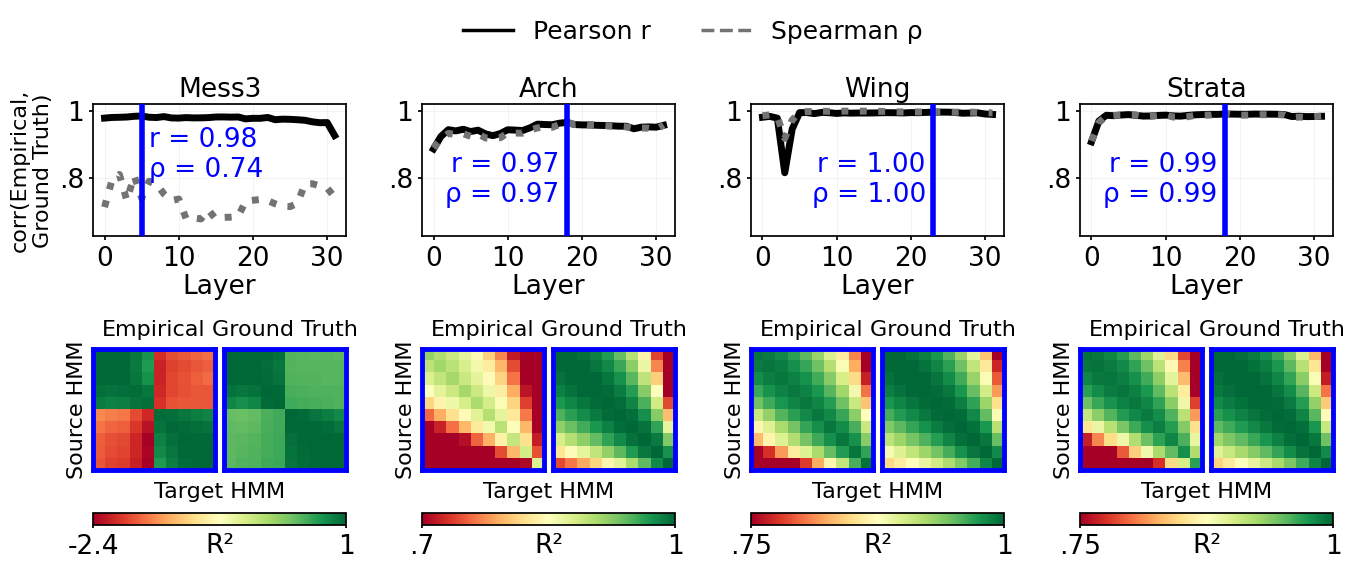

In [409]:
import matplotlib
matplotlib.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'font.weight': 'light',
})

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr
from matplotlib.lines import Line2D

sns.set_context('notebook')

def fmt_tick(v):
    """Format tick: 1.00→1, 0.75→.75, -2.402→-2.4"""
    if v == int(v):
        return str(int(v))
    s = f'{v:.2g}'
    if '.' in s and abs(v) < 1:
        s = s.lstrip('0')
    return s

cross_df = cross_df[cross_df['hmm'] != 'Spiral']
gt_df = gt_df[gt_df['hmm'] != 'Spiral']

hmm_order = ['Mess3', 'Arch', 'Wing', 'Strata']

CONN_COLOR = '0.55'
VERT_COLOR = 'blue'

fig = plt.figure(figsize=(16, 5.5))
fig.patch.set_facecolor('white')
fig.patch.set_edgecolor('white')
fig.patch.set_linewidth(0)

outer = fig.add_gridspec(2, 4, height_ratios=[1, 1.8], hspace=0.3, wspace=0.3)

# Precompute
all_pearson = []
all_spearman = []
precomputed = {}

for hmm in hmm_order:
    c = cross_df[cross_df['hmm'] == hmm]
    g = gt_df[gt_df['hmm'] == hmm]
    params = sorted(c['train'].unique())
    n_params = len(params)
    layers = sorted(c['layer'].unique())

    gt_matrix = np.zeros((n_params, n_params))
    for pi, p_train in enumerate(params):
        for pj, p_test in enumerate(params):
            gt_matrix[pi, pj] = g[(g['train'] == p_train) & (g['test'] == p_test)]['R2'].mean()

    triu_idx = np.triu_indices(n_params, k=1)
    gt_vec = gt_matrix[triu_idx]

    pearson_vals = []
    spearman_vals = []
    emp_matrices = {}
    for layer in layers:
        emp_matrix = np.zeros((n_params, n_params))
        for pi, p_train in enumerate(params):
            for pj, p_test in enumerate(params):
                emp_matrix[pi, pj] = c[(c['train'] == p_train) & (c['test'] == p_test) & (c['layer'] == layer)]['R2'].mean()
        emp_matrices[layer] = emp_matrix
        emp_vec = emp_matrix[triu_idx]
        pr, _ = pearsonr(gt_vec, emp_vec)
        sr, _ = spearmanr(gt_vec, emp_vec)
        pearson_vals.append(pr)
        spearman_vals.append(sr)

    pearson_vals = np.array(pearson_vals)
    spearman_vals = np.array(spearman_vals)
    all_pearson.extend(pearson_vals)
    all_spearman.extend(spearman_vals)

    best_layer_idx = np.argmax(pearson_vals)
    best_layer = layers[best_layer_idx]

    # Per-HMM color range
    hmm_vmin = min(gt_matrix.min(), emp_matrices[best_layer].min())
    hmm_vmax = max(gt_matrix.max(), emp_matrices[best_layer].max())

    precomputed[hmm] = {
        'layers': layers, 'params': params,
        'pearson': pearson_vals, 'spearman': spearman_vals,
        'gt_matrix': gt_matrix, 'emp_best': emp_matrices[best_layer],
        'best_layer': best_layer,
        'vmin': hmm_vmin, 'vmax': hmm_vmax,
    }

# Shared y limits
all_vals = all_pearson + all_spearman
shared_ylim = (min(all_vals) - 0.05, max(all_vals) + 0.02)

# Legend
legend_handles = [
    Line2D([], [], color='black', lw=2.5, label='Pearson r'),
    Line2D([], [], color='0.45', lw=2.5, ls='--', label='Spearman ρ'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=2,
           fontsize=18, frameon=False, bbox_to_anchor=(0.5, 0.95))

for i, hmm in enumerate(hmm_order):
    d = precomputed[hmm]
    layers = d['layers']
    best_layer = d['best_layer']

    # Top: correlation curve
    ax_corr = fig.add_subplot(outer[0, i])

    # Bottom: two heatmaps side by side
    inner_bot = outer[1, i].subgridspec(1, 2, wspace=0.08)
    ax_emp_hm = fig.add_subplot(inner_bot[0])
    ax_gt_hm = fig.add_subplot(inner_bot[1])

    # Correlation curves
    ax_corr.plot(layers, d['pearson'], color='black', lw=5)
    ax_corr.plot(layers, d['spearman'], color='0.45', lw=5, ls=':')
    ax_corr.axvline(best_layer, color=VERT_COLOR, lw=4, zorder=5)

    best_layer_idx = list(layers).index(best_layer)
    best_r = d['pearson'][best_layer_idx]
    best_rho = d['spearman'][best_layer_idx]
    if hmm == 'Mess3':
        xy = (best_layer + 1, shared_ylim[1] - 0.065)
        ha = 'left'
    else:
        xy = (best_layer - 1, shared_ylim[1] - 0.14)
        ha = 'right'
    ax_corr.annotate(f'r = {best_r:.2f}\nρ = {best_rho:.2f}',
                     xy=xy, fontsize=19, color=VERT_COLOR, ha=ha, va='top')

    ax_corr.set_ylim(shared_ylim)
    ax_corr.set_title(hmm, fontsize=19)
    ax_corr.tick_params(axis='both', labelsize=19, length=3)
    ax_corr.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: fmt_tick(v)))
    ax_corr.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: fmt_tick(v)))
    ax_corr.grid(True, alpha=0.2, linewidth=0.5)
    ax_corr.set_xticks([0, 10, 20, 30])
    ax_corr.set_xlabel('Layer', fontsize=19, labelpad=2)
    if i == 0:
        ax_corr.set_ylabel('corr(Empirical,\nGround Truth)', fontsize=16)

    # Per-HMM heatmap range
    if hmm == 'Arch':
        vmin, vmax = 0.7, 1.0
    elif hmm in ['Wing', 'Strata']:
        vmin, vmax = 0.75, 1.0
    else:
        vmin, vmax = d['vmin'], d['vmax']
    cmap = plt.cm.RdYlGn

    for ax, matrix, title in [(ax_emp_hm, d['emp_best'], 'Empirical'),
                               (ax_gt_hm, d['gt_matrix'], 'Ground Truth')]:
        im = ax.imshow(matrix, cmap=cmap, vmin=vmin, vmax=vmax, aspect='equal')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.tick_params(left=False, right=False, top=False, bottom=False)
        ax.xaxis.set_visible(False)
        ax.yaxis.set_visible(False)

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor(VERT_COLOR)
            spine.set_linewidth(3.5)

    # Labels above heatmaps
    ax_emp_hm.annotate('Empirical', xy=(0.5, 1.08), xycoords='axes fraction',
                        fontsize=16, ha='center', va='bottom')
    ax_gt_hm.annotate('Ground Truth', xy=(0.5, 1.08), xycoords='axes fraction',
                        fontsize=16, ha='center', va='bottom')

    params = d['params']
    n_params = len(params)

    for ax in [ax_emp_hm, ax_gt_hm]:
        ax.set_xticks([])
        ax.set_yticks([])
        ax.tick_params(left=False, right=False, top=False, bottom=False)
        ax.xaxis.set_visible(False)
        ax.yaxis.set_visible(False)

    # Source HMM on left of every empirical heatmap
    ax_emp_hm.yaxis.set_visible(True)
    ax_emp_hm.set_yticks([])
    ax_emp_hm.set_ylabel('Source HMM', fontsize=16)

    # Target HMM centered between the two heatmaps
    mid_x = (ax_emp_hm.get_position().x0 + ax_gt_hm.get_position().x1) / 2
    fig.text(mid_x, ax_emp_hm.get_position().y0 - 0.02, 'Target HMM',
             fontsize=16, ha='center', va='top')

    # Horizontal colorbar below heatmap pair
    pos_emp = ax_emp_hm.get_position()
    pos_gt = ax_gt_hm.get_position()
    cbar_ax = fig.add_axes([
        pos_emp.x0,
        pos_emp.y0 - 0.1,
        pos_gt.x1 - pos_emp.x0,
        pos_emp.height / n_params
    ])
    fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
    cbar_ax.set_xticks([vmin, vmax])
    cbar_ax.set_xticklabels([fmt_tick(vmin), fmt_tick(vmax)])
    cbar_ax.tick_params(labelsize=19, length=2)
    cbar_ax.annotate('R²', xy=(0.5, -0.6), xycoords='axes fraction',
                      fontsize=19, ha='center', va='top')

plt.tight_layout()
plt.savefig('plots/within_r2.pdf', bbox_inches='tight')
plt.show()
plt.close()

In [407]:
d = precomputed['Mess3']
best_idx = list(d['layers']).index(d['best_layer'])
print(f"Best Pearson layer: {d['best_layer']}")
print(f"Pearson at that layer: {d['pearson'][best_idx]:.4f}")
print(f"Spearman at that layer: {d['spearman'][best_idx]:.4f}")
print(f"Peak Spearman: {max(d['spearman']):.4f} at layer {d['layers'][np.argmax(d['spearman'])]}")

Best Pearson layer: 5
Pearson at that layer: 0.9842
Spearman at that layer: 0.7394
Peak Spearman: 0.8101 at layer 2


## Reduced resolution R2

In [417]:
# Load reduced R² CSV
redr2_df = pd.read_csv('final_redr2_csv/r2_orderk_qwen35_9b.csv')

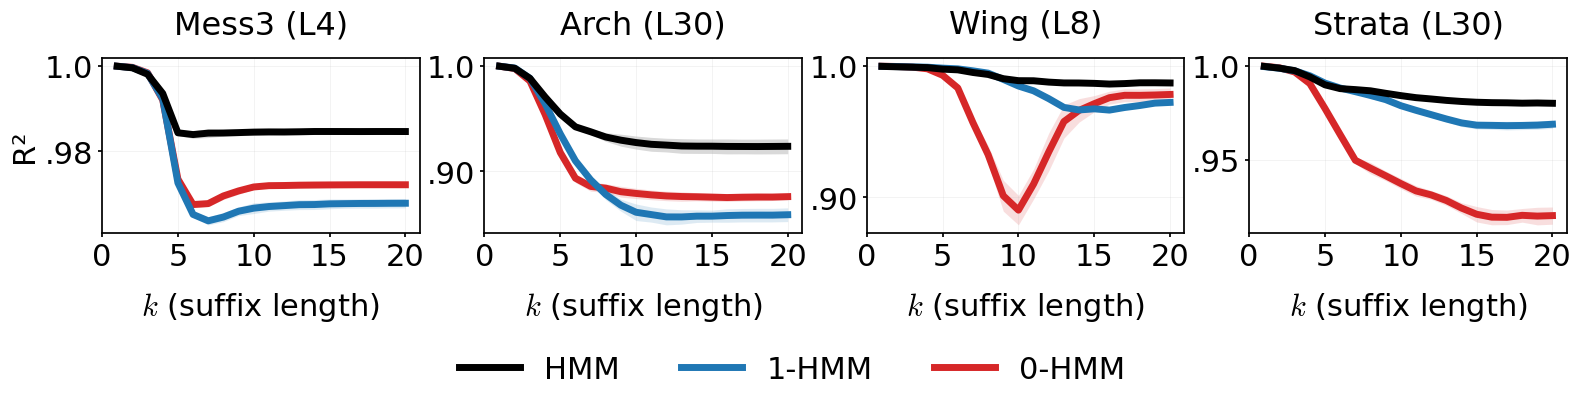

In [378]:
import matplotlib
matplotlib.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'font.weight': 'light',
})

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

sns.set_context('notebook')

tab10 = sns.color_palette('tab10')

def fmt_tick(v):
    if v == int(v):
        s = f'{v:.1f}'
    else:
        s = f'{v:.2f}'
    if '.' in s and -1 < v < 1:
        s = s.lstrip('0')
    return s

# Best layer per HMM from regular R² CSV
best_layers = {}
for hmm in ['Mess3', 'Arch', 'Wing', 'Strata']:
    sub = r2_df[(r2_df['hmm'] == hmm) & (r2_df['target'] == 'real')]
    best_layers[hmm] = int(sub.groupby('layer')['R2'].mean().idxmax())

dist_colors = {'real': 'black', 'order-1': tab10[0], 'order-0': tab10[3]}
dist_labels = {'real': 'HMM', 'order-1': '1-HMM', 'order-0': '0-HMM'}

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))

for i, (hmm, param) in enumerate(targets):
    ax = axes[i]
    layer = best_layers[hmm]

    for dist_name in ['order-0', 'order-1', 'real']:
        s = redr2_df[(redr2_df['hmm'] == hmm) & (redr2_df['param'] == param) &
                      (redr2_df['dist'] == dist_name) & (redr2_df['layer'] == layer)]
        stats = s.groupby('k')['R2'].agg(['mean', 'sem']).reset_index()
        lw = 5
        ax.plot(stats['k'], stats['mean'], '-',
                color=dist_colors[dist_name], lw=lw, label=dist_labels[dist_name])
        ax.fill_between(stats['k'],
                        stats['mean'] - 1.96 * stats['sem'],
                        stats['mean'] + 1.96 * stats['sem'],
                        color=dist_colors[dist_name], alpha=0.15, linewidth=0)

    ax.set_title(f'{hmm} (L{layer})', fontsize=23, pad=18)
    ax.set_xticks([0, 5, 10, 15, 20])
    ax.set_xlabel('$k$ (suffix length)', fontsize=22, labelpad=14)
    ax.tick_params(axis='both', labelsize=22, length=3)
    ax.grid(True, alpha=0.2, linewidth=0.5)
    if hmm == 'Mess3':
        ax.set_yticks([0.98, 1.0])
        ax.set_yticklabels([fmt_tick(0.98), fmt_tick(1.0)])
    elif hmm == 'Strata':
        ax.set_yticks([0.95, 1.0])
        ax.set_yticklabels([fmt_tick(0.95), fmt_tick(1.0)])
    if i == 0:
        ax.set_ylabel('R²', fontsize=22)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: fmt_tick(v)))

# Legend below
legend_handles = [Line2D([], [], color=dist_colors[d], lw=5, label=dist_labels[d])
                  for d in ['real', 'order-1', 'order-0']]
fig.legend(handles=legend_handles, loc='lower center', ncol=3,
           fontsize=22, frameon=False, bbox_to_anchor=(0.5, -0.2))

plt.tight_layout(w_pad=0)
plt.savefig('plots/redr2.pdf', bbox_inches='tight')
plt.show()
plt.close()

## Obsprob plots

In [418]:
# Load obsprob CSV
obsprob_df = pd.read_csv('final_obsprob_csv/obsprob_qwen35_9b.csv')

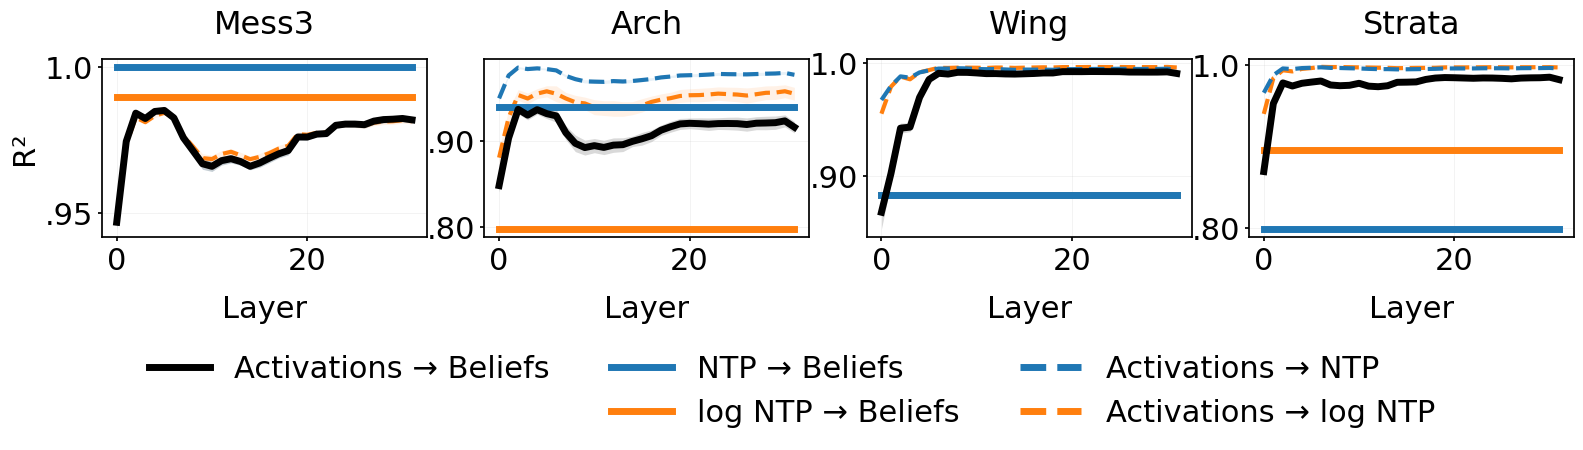

In [419]:
import matplotlib
matplotlib.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'font.weight': 'light',
})

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

sns.set_context('notebook')

tab10 = sns.color_palette('tab10')

def fmt_tick(v):
    if v == int(v):
        s = f'{v:.1f}'
    else:
        s = f'{v:.2f}'
    if '.' in s and -1 < v < 1:
        s = s.lstrip('0')
    return s

target_styles = {
    'real':            ('black',   5, '-',  'Activations → Beliefs'),
    'act→ntp':         (tab10[0],  3, '--', 'Activations → NTP'),
    'act→log_ntp':     (tab10[1],  3, '--', 'Activations → log NTP'),
    'ntp→beliefs':     (tab10[0],  5, '-',  'NTP → Beliefs'),
    'log_ntp→beliefs': (tab10[1],  5, '-',  'log NTP → Beliefs'),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))

for i, (hmm, param) in enumerate(targets):
    ax = axes[i]

    # Draw bottom to top: dotted orange, solid orange, dotted blue, solid blue, black
    for tname in ['act→log_ntp', 'log_ntp→beliefs', 'act→ntp', 'ntp→beliefs']:
        color, lw, ls, label = target_styles[tname]
        s = obsprob_df[(obsprob_df['hmm'] == hmm) & (obsprob_df['param'] == param) &
                        (obsprob_df['target'] == tname)]
        stats = s.groupby('layer')['R2'].agg(['mean', 'sem']).reset_index()
        ax.plot(stats['layer'], stats['mean'], ls=ls, color=color, lw=lw)
        ax.fill_between(stats['layer'],
                        stats['mean'] - 1.96 * stats['sem'],
                        stats['mean'] + 1.96 * stats['sem'],
                        color=color, alpha=0.1, linewidth=0)

    # Real R² on top
    r2_sub = r2_df[(r2_df['hmm'] == hmm) & (r2_df['param'] == param) & (r2_df['target'] == 'real')]
    stats = r2_sub.groupby('layer')['R2'].agg(['mean', 'sem']).reset_index()
    ax.plot(stats['layer'], stats['mean'], color='black', lw=5)
    ax.fill_between(stats['layer'],
                    stats['mean'] - 1.96 * stats['sem'],
                    stats['mean'] + 1.96 * stats['sem'],
                    color='black', alpha=0.15, linewidth=0)

    ax.set_title(f'{hmm}', fontsize=23, pad=18)
    ax.set_xlabel('Layer', fontsize=22, labelpad=14)
    ax.tick_params(axis='both', labelsize=22, length=3)
    ax.grid(True, alpha=0.2, linewidth=0.5)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: fmt_tick(v)))
    if i == 0:
        ax.set_ylabel('R²', fontsize=22)

# Legend
legend_order = ['real', None, 'ntp→beliefs', 'log_ntp→beliefs', 'act→ntp', 'act→log_ntp']
legend_handles = []
legend_labels = []
for tname in legend_order:
    if tname is None:
        legend_handles.append(Line2D([], [], lw=0, alpha=0))
        legend_labels.append('')
    else:
        color, lw, ls, label = target_styles[tname]
        legend_handles.append(Line2D([], [], color=color, lw=5, ls=ls))
        legend_labels.append(label)
fig.legend(handles=legend_handles, labels=legend_labels, loc='lower center', ncol=3,
           fontsize=22, frameon=False, bbox_to_anchor=(0.5, -0.325))

plt.tight_layout(w_pad=0)
plt.savefig('plots/obsprob.pdf', bbox_inches='tight')
plt.show()
plt.close()

In [428]:
for param in sorted(obsprob_df[obsprob_df['hmm']=='Arch']['param'].unique()):
    ntp_b = obsprob_df[(obsprob_df['hmm']=='Arch') & (obsprob_df['param']==param) & (obsprob_df['target']=='ntp→beliefs')]['R2'].mean()
    act_b = r2_df[(r2_df['hmm']=='Arch') & (r2_df['param']==param) & (r2_df['target']=='real')].groupby('layer')['R2'].mean().max()
    print(f'{param}: act→beliefs={act_b:.4f}, NTP→beliefs={ntp_b:.4f}, gap={act_b - ntp_b:.4f}')

a=0.9: act→beliefs=0.9375, NTP→beliefs=0.9407, gap=-0.0031
a=0.91: act→beliefs=0.9321, NTP→beliefs=0.9330, gap=-0.0010
a=0.92: act→beliefs=0.9258, NTP→beliefs=0.9232, gap=0.0026
a=0.93: act→beliefs=0.9186, NTP→beliefs=0.9169, gap=0.0018
a=0.94: act→beliefs=0.9133, NTP→beliefs=0.9075, gap=0.0057
a=0.95: act→beliefs=0.9092, NTP→beliefs=0.8910, gap=0.0183
a=0.96: act→beliefs=0.9048, NTP→beliefs=0.8746, gap=0.0302
a=0.97: act→beliefs=0.8994, NTP→beliefs=0.8503, gap=0.0490
a=0.98: act→beliefs=0.8884, NTP→beliefs=0.8109, gap=0.0775
a=0.99: act→beliefs=0.8843, NTP→beliefs=0.7403, gap=0.1440


## Steering intervention gap

In [322]:
# Load steering CSV
steer_df = pd.read_csv('final_steer_csv/steer_qwen35_9b.csv')
steer_df = steer_df[steer_df['hmm'] != 'Spiral']

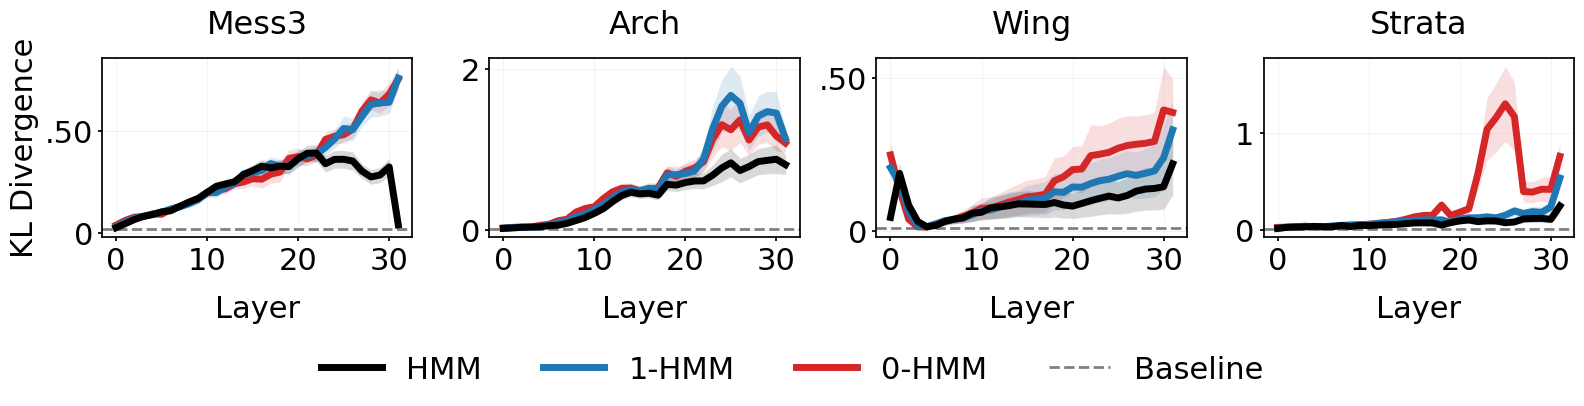

In [361]:
import matplotlib
matplotlib.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'font.weight': 'light',
})

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

sns.set_context('notebook')

tab10 = sns.color_palette('tab10')

def fmt_tick(v):
    if v == int(v):
        return str(int(v))
    s = f'{v:.2f}'
    if '.' in s and -1 < v < 1:
        s = s.lstrip('0')
    return s

# Load steering CSV
steer_df = pd.read_csv('final_steer_csv/steer_qwen35_9b.csv')
steer_df = steer_df[steer_df['hmm'] != 'Spiral']

dist_colors = {'real': 'black', 'order-1': tab10[0], 'order-0': tab10[3]}
dist_labels = {'real': 'HMM', 'order-1': '1-HMM', 'order-0': '0-HMM'}

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))

for i, (hmm, param) in enumerate(targets):
    ax = axes[i]

    sub = steer_df[(steer_df['hmm'] == hmm) & (steer_df['param'] == param)]

    # Baseline KL (layer=-1, one per seed)
    baseline_kl = sub[sub['dist'] == 'baseline']['KL'].mean()

    for dist_name in ['order-0', 'order-1', 'real']:
        s = sub[sub['dist'] == dist_name]
        stats = s.groupby('layer')['KL'].agg(['mean', 'sem']).reset_index()
        ax.plot(stats['layer'], stats['mean'], '-',
                color=dist_colors[dist_name], lw=5)
        ax.fill_between(stats['layer'],
                        stats['mean'] - 1.96 * stats['sem'],
                        stats['mean'] + 1.96 * stats['sem'],
                        color=dist_colors[dist_name], alpha=0.15, linewidth=0)

    ax.axhline(baseline_kl, color='0.5', lw=2, ls='--', zorder=0, label='Baseline')
    ax.set_title(f'{hmm}', fontsize=23, pad=18)
    ax.set_xticks([0, 10, 20, 30])
    ax.set_xlabel('Layer', fontsize=22, labelpad=14)
    ax.tick_params(axis='both', labelsize=22, length=3)
    ax.grid(True, alpha=0.2, linewidth=0.5)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: fmt_tick(v)))
    if i == 0:
        ax.set_ylabel('KL Divergence', fontsize=22)

# Legend below
legend_handles = [Line2D([], [], color=dist_colors[d], lw=5, label=dist_labels[d])
                  for d in ['real', 'order-1', 'order-0']]
legend_handles.append(Line2D([], [], color='0.5', lw=2, ls='--', label='Baseline'))
fig.legend(handles=legend_handles, loc='lower center', ncol=4,
           fontsize=22, frameon=False, bbox_to_anchor=(0.5, -0.2))

plt.tight_layout(w_pad=0)
plt.savefig('plots/steer_orderk.pdf', bbox_inches='tight')
plt.show()
plt.close()